# Case Técnico — Especialista de Dados I

**BigQuery / SQL → Data Quality, filtros, agregações e regras em escala**  
**Python → estatística, visualização, interpretação e Machine Learning**

Objetivos do case:
- avaliar qualidade e consistência dos dados;
- análise do negócio;
- insights antes do modelo preditivo;

In [66]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from gb_ml.io import estimate_query_bytes, read_query, table_metadata

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

PROJECT_ID = "gms-prod-01"
BQ_LOCATION = "us-east4"
TABLE_ID = "gms-prod-01.projeto_gb.fact_vendas"
STG_TABLE_ID = "gms-prod-01.projeto_gb.stg_fact_vendas"

START_DATE = "2025-11-01"
END_DATE = "2026-06-30"

DATE_FILTER = f"DATE(dt_hr_venda) BETWEEN DATE '{START_DATE}' AND DATE '{END_DATE}'"

## Consumo Bigquery

Antes de cada consulta, fazemos um **dry-run** para estimar bytes processados.

In [67]:
def run_bq(sql: str, label: str | None = None) -> pd.DataFrame:
    bytes_processed = estimate_query_bytes(
        sql,
        project_id=PROJECT_ID,
        location=BQ_LOCATION,
    )
    mb = bytes_processed / 1024**2
    print(f"[BigQuery] {label or 'query'} | estimativa processada: {mb:,.2f} MB")

    return read_query(
        sql,
        project_id=PROJECT_ID,
        location=BQ_LOCATION,
    )

# 1. Dados — fonte, schema e período

In [68]:
metadata, bq_schema = table_metadata(
    TABLE_ID,
    project_id=PROJECT_ID,
    location=BQ_LOCATION,
)

display(pd.DataFrame([metadata]))
display(bq_schema)

,table_id,num_rows,num_bytes,created,modified,location,partitioning_type,partition_field,clustering_fields
0,gms-prod-01.projeto_gb.fact_vendas,89566,6876011,2026-10-04 18:20:15.053000+00:00,2026-10-04 18:20:15.054000+00:00,us-east4,TimePartitioning,dt_hr_venda,"[des_canal_venda_final_agrup, des_categoria_ma..."


,name,field_type,mode,description
0,dt_hr_venda,DATETIME,NULLABLE,None
1,des_canal_venda_final_agrup,STRING,NULLABLE,None
2,des_categoria_material,STRING,NULLABLE,None
3,receita_aprovada,NUMERIC,NULLABLE,None
4,qt_material,INTEGER,NULLABLE,None
5,nr_pedidos,INTEGER,NULLABLE,None
6,vlr_venda_desconto,NUMERIC,NULLABLE,None


In [69]:
sql_overview = f"""
SELECT
  COUNT(*) AS linhas,
  MIN(dt_hr_venda) AS dt_min,
  MAX(dt_hr_venda) AS dt_max,
  COUNT(DISTINCT DATE(dt_hr_venda)) AS dias,
  COUNT(DISTINCT des_canal_venda_final_agrup) AS canais,
  COUNT(DISTINCT des_categoria_material) AS categorias_brutas
FROM `{TABLE_ID}`
WHERE 1=1
"""

overview = run_bq(sql_overview, "overview")
display(overview)

[BigQuery] overview | estimativa processada: 2.46 MB


,linhas,dt_min,dt_max,dias,canais,categorias_brutas
0,89566,2025-11-01,2026-06-30 23:00:00,242,2,5349


## 1.1 KPIs gerais

Antes de entrar em qualidade de dados, fazemos uma leitura executiva do negócio: tamanho da operação, participação de App/Site e composição por categoria.

In [70]:
sql_global_kpis = f"""
SELECT
  SUM(qt_material) AS qt_material,
  SUM(nr_pedidos) AS nr_pedidos,
  CAST(SUM(receita_aprovada) AS FLOAT64) AS receita_aprovada,

  SAFE_DIVIDE(
    CAST(SUM(receita_aprovada) AS FLOAT64),
    SUM(qt_material)
  ) AS preco_medio_item,

  SAFE_DIVIDE(
    CAST(SUM(receita_aprovada) AS FLOAT64),
    SUM(nr_pedidos)
  ) AS ticket_medio,

  SAFE_DIVIDE(
    SUM(qt_material),
    SUM(nr_pedidos)
  ) AS itens_por_pedido

FROM `{TABLE_ID}`
WHERE {DATE_FILTER}
"""

global_kpis = run_bq(
    sql_global_kpis,
    "KPIs globais",
)

display(global_kpis.T.rename(columns={0: "valor"}))

[BigQuery] KPIs globais | estimativa processada: 3.42 MB


,valor
qt_material,9896201
nr_pedidos,6520895
receita_aprovada,"490,309,826.6200"
preco_medio_item,49.5453
ticket_medio,75.1906
itens_por_pedido,1.5176


### Itens vendidos por canal

Volume absoluto na tabela e, no gráfico, a participação de cada canal em `qt_material` e em `nr_pedidos`.

[BigQuery] itens vendidos por canal | estimativa processada: 3.89 MB


,des_canal_venda_final_agrup,qt_material,nr_pedidos,receita_aprovada,share_itens,share_pedidos
0,App,7727618,5088139,"373,473,429.0900",0.7809,0.7803
1,Site,2168583,1432756,"116,836,397.5300",0.2191,0.2197


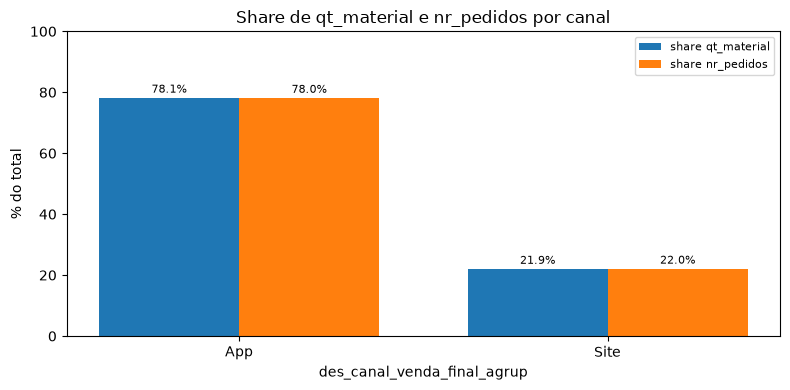

In [71]:
sql_items_by_channel = f"""
SELECT
  des_canal_venda_final_agrup,
  SUM(qt_material) AS qt_material,
  SUM(nr_pedidos) AS nr_pedidos,
  CAST(SUM(receita_aprovada) AS FLOAT64) AS receita_aprovada,

  SAFE_DIVIDE(
    SUM(qt_material),
    SUM(SUM(qt_material)) OVER ()
  ) AS share_itens,

  SAFE_DIVIDE(
    SUM(nr_pedidos),
    SUM(SUM(nr_pedidos)) OVER ()
  ) AS share_pedidos

FROM `{TABLE_ID}`
WHERE {DATE_FILTER}
GROUP BY 1
ORDER BY qt_material DESC
"""

items_by_channel = run_bq(
    sql_items_by_channel,
    "itens vendidos por canal",
)

display(items_by_channel)

x = np.arange(len(items_by_channel))
largura = 0.38

fig, ax = plt.subplots(figsize=(8, 4))
barras_itens = ax.bar(
    x - largura / 2,
    items_by_channel["share_itens"] * 100,
    largura,
    label="share qt_material",
)
barras_pedidos = ax.bar(
    x + largura / 2,
    items_by_channel["share_pedidos"] * 100,
    largura,
    label="share nr_pedidos",
)
for barras in (barras_itens, barras_pedidos):
    ax.bar_label(barras, fmt="%.1f%%", fontsize=8, padding=2)

ax.set_xticks(x)
ax.set_xticklabels(items_by_channel["des_canal_venda_final_agrup"])
ax.set_title("Share de qt_material e nr_pedidos por canal")
ax.set_xlabel("des_canal_venda_final_agrup")
ax.set_ylabel("% do total")
ax.set_ylim(0, 100)
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

### Itens vendidos por categoria

Ao explorar os dados foi identificado categorias inválidas, sem descrição com texto. Agrupadas como CATEGORIA_INVALIDA.

[BigQuery] itens vendidos por categoria | estimativa processada: 4.72 MB


,des_categoria_material,qt_material,nr_pedidos,receita_aprovada,share_itens_total,share_itens_validos
0,PERFUMARIA FEMININA,2136959,1448905,"119,668,505.1400",0.2159,0.2295
1,CORPO E BANHO,2113614,1281907,"71,702,424.3500",0.2136,0.2270
2,PERFUMARIA MASCULINA,1691222,1161579,"126,738,394.4100",0.1709,0.1816
3,PERF. DE ENTRADA E DEOS,1209788,820181,"51,165,435.4100",0.1222,0.1299
4,CABELOS,656521,313113,"16,448,636.8000",0.0663,0.0705
5,MAQUIAGEM,587234,399524,"17,282,397.6000",0.0593,0.0631
6,CATEGORIA_INVALIDA,583622,382362,"29,264,917.9500",0.0590,NaN
7,GIFTS,475554,390875,"49,485,210.3000",0.0481,0.0511
8,FACIAL,441687,322449,"8,553,904.6600",0.0446,0.0474


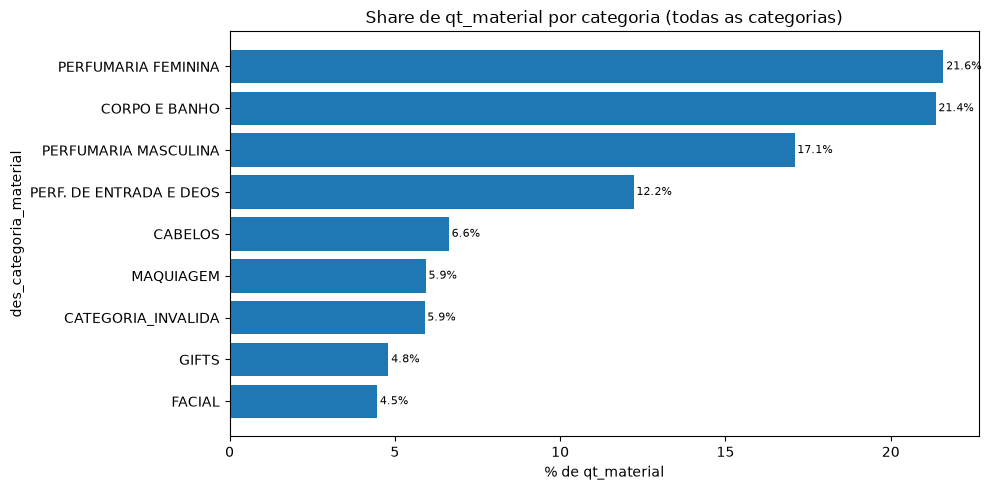

In [121]:
sql_items_by_category = f"""
WITH base AS (
  SELECT
    IF(
      SAFE_CAST(des_categoria_material AS NUMERIC) IS NOT NULL,
      'CATEGORIA_INVALIDA',
      des_categoria_material
    ) AS des_categoria_material,
    qt_material,
    nr_pedidos,
    receita_aprovada
  FROM `{TABLE_ID}`
  WHERE {DATE_FILTER}
)
SELECT
  des_categoria_material,
  SUM(qt_material) AS qt_material,
  SUM(nr_pedidos) AS nr_pedidos,
  CAST(SUM(receita_aprovada) AS FLOAT64) AS receita_aprovada,

  -- share sobre o total da base (inclui a inválida)
  SAFE_DIVIDE(
    SUM(qt_material),
    SUM(SUM(qt_material)) OVER ()
  ) AS share_itens_total,

  -- share só entre as categorias válidas (NULL para a inválida)
  IF(
    des_categoria_material = 'CATEGORIA_INVALIDA',
    NULL,
    SAFE_DIVIDE(
      SUM(qt_material),
      SUM(IF(des_categoria_material != 'CATEGORIA_INVALIDA', SUM(qt_material), 0)) OVER ()
    )
  ) AS share_itens_validos

FROM base
GROUP BY 1
ORDER BY qt_material DESC
"""

items_by_category = run_bq(
    sql_items_by_category,
    "itens vendidos por categoria",
)

display(items_by_category)

fig, ax = plt.subplots(figsize=(10, 5))
ordered = items_by_category.sort_values("share_itens_total")
barras = ax.barh(
    ordered["des_categoria_material"],
    ordered["share_itens_total"] * 100,
)
ax.bar_label(barras, fmt="%.1f%%", fontsize=8, padding=2)
ax.set_title("Share de qt_material por categoria (todas as categorias)")
ax.set_xlabel("% de qt_material")
ax.set_ylabel("des_categoria_material")
fig.tight_layout()
plt.show()

### Evolução mensal das categorias — App × Site

Share mensal de cada categoria em `qt_material`, dentro de cada canal (cada mês/canal soma 100%). Linhas em tons próximos de azul/verde-água (mais escuro = categoria de maior volume) e sem legenda para não poluir; o valor exato de cada categoria está na tabela acima.

Permite ver se o mix de App e Site é semelhante e quais categorias ganham ou perdem relevância ao longo do período.

In [73]:
sql_category_channel_month = f"""
WITH base AS (
  SELECT
    DATE_TRUNC(DATE(dt_hr_venda), MONTH) AS mes,
    des_canal_venda_final_agrup,
    des_categoria_material,
    SUM(qt_material) AS qt_material

  FROM `{TABLE_ID}`
  WHERE {DATE_FILTER}
    AND SAFE_CAST(des_categoria_material AS NUMERIC) IS NULL
  GROUP BY 1, 2, 3
)
SELECT
  mes,
  des_canal_venda_final_agrup,
  des_categoria_material,
  qt_material,

  SAFE_DIVIDE(
    qt_material,
    SUM(qt_material) OVER (
      PARTITION BY mes, des_canal_venda_final_agrup
    )
  ) AS share_itens_mes_canal

FROM base
ORDER BY mes, des_canal_venda_final_agrup, qt_material DESC
"""

category_channel_month = run_bq(
    sql_category_channel_month,
    "categorias por mês e canal",
)

category_channel_month["mes"] = pd.to_datetime(
    category_channel_month["mes"]
)

display(category_channel_month.head(20))

[BigQuery] categorias por mês e canal | estimativa processada: 3.14 MB


,mes,des_canal_venda_final_agrup,des_categoria_material,qt_material,share_itens_mes_canal
0,2025-11-01,App,PERFUMARIA FEMININA,734524,0.2784
1,2025-11-01,App,CORPO E BANHO,472295,0.1790
2,2025-11-01,App,PERFUMARIA MASCULINA,465037,0.1763
3,2025-11-01,App,PERF. DE ENTRADA E DEOS,246359,0.0934
4,2025-11-01,App,CABELOS,242561,0.0919
5,2025-11-01,App,FACIAL,208255,0.0789
6,2025-11-01,App,MAQUIAGEM,186840,0.0708
7,2025-11-01,App,GIFTS,82354,0.0312
8,2025-11-01,Site,PERFUMARIA FEMININA,188612,0.2547
9,2025-11-01,Site,PERFUMARIA MASCULINA,147377,0.1990


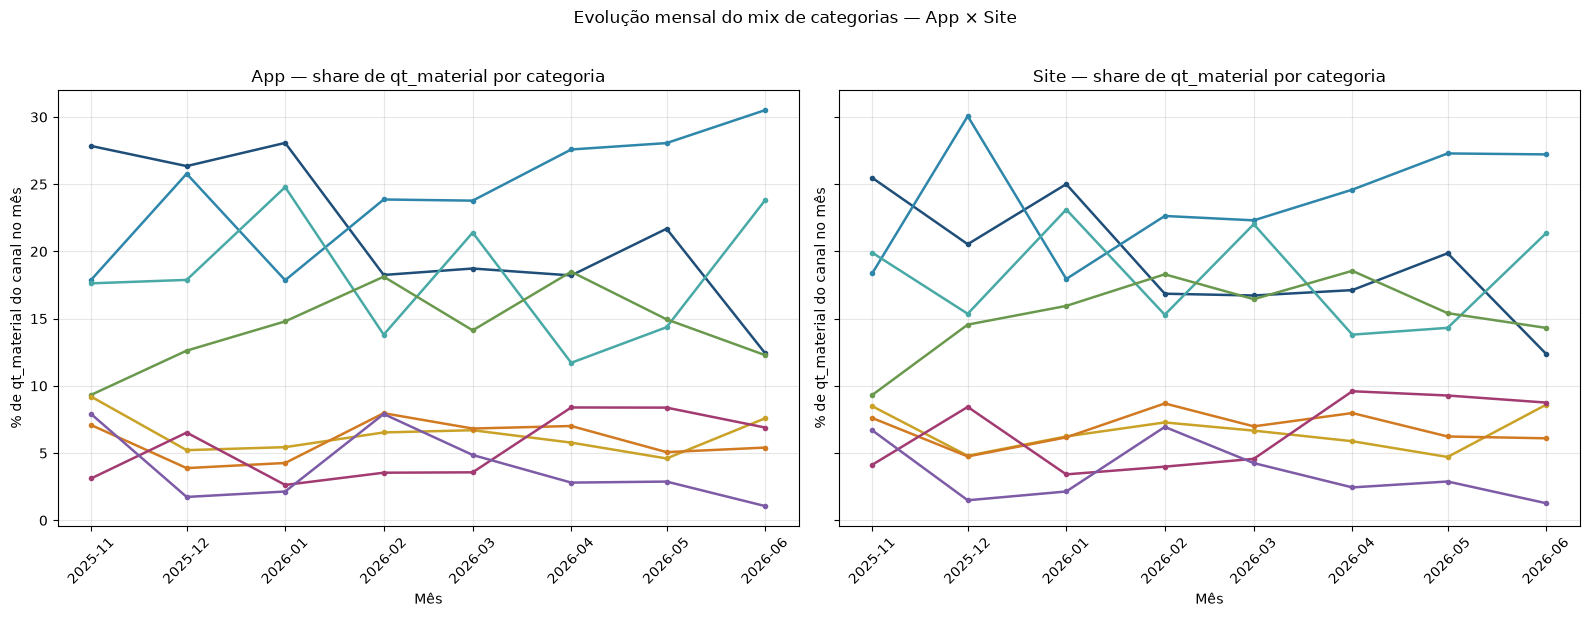

In [122]:
categorias = (
    category_channel_month
    .groupby("des_categoria_material")["qt_material"].sum()
    .sort_values(ascending=False)
    .index.tolist()
)
paleta = [
    "#1f4e79",  # azul-marinho
    "#2e86ab",  # azul
    "#48a9a6",  # verde-água
    "#6a994e",  # verde-oliva
    "#c9a227",  # mostarda
    "#d17a22",  # laranja queimado
    "#a23b72",  # vinho/magenta
    "#7d5ba6",  # roxo
]
cores = dict(zip(categorias, paleta))

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax, canal in zip(axes, ["App", "Site"]):
    share = (
        category_channel_month[category_channel_month["des_canal_venda_final_agrup"] == canal]
        .pivot(index="mes", columns="des_categoria_material", values="share_itens_mes_canal")
        .reindex(columns=categorias)
        .sort_index()
        * 100
    )
    for categoria in categorias:
        ax.plot(share.index, share[categoria], color=cores[categoria], linewidth=1.8, marker="o", markersize=3)

    ax.set_title(f"{canal} — share de qt_material por categoria")
    ax.set_xlabel("Mês")
    ax.set_ylabel("% de qt_material do canal no mês")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(alpha=0.3)

fig.suptitle("Evolução mensal do mix de categorias — App × Site", y=1.02)
fig.tight_layout()
plt.show()

## 1.2 Precisão monetária no BigQuery

Na carga original foram encontrados números monetários com artefatos de ponto flutuante, por exemplo `3731.5600000000004`.

**Decisão de engenharia:** preservar a carga bruta em `stg_fact_vendas` e usar `NUMERIC` arredondado a 2 casas em `fact_vendas`. Não usamos `BIGNUMERIC`, pois as casas adicionais representam ruído de representação e não precisão financeira útil.

In [75]:
sql_precision = f"""
SELECT
  COUNT(*) AS linhas,
  COUNTIF(receita_aprovada != ROUND(receita_aprovada, 2)) AS receita_acima_2_casas,
  COUNTIF(vlr_venda_desconto != ROUND(vlr_venda_desconto, 2)) AS desconto_acima_2_casas
FROM `{TABLE_ID}`
WHERE {DATE_FILTER}
"""

precision_check = run_bq(sql_precision, "precisão monetária")
display(precision_check)

display(
    bq_schema[
        bq_schema["name"].isin(["receita_aprovada", "vlr_venda_desconto"])
    ]
)

[BigQuery] precisão monetária | estimativa processada: 3.42 MB


,linhas,receita_acima_2_casas,desconto_acima_2_casas
0,89566,0,0


,name,field_type,mode,description
3,receita_aprovada,NUMERIC,NULLABLE,None
6,vlr_venda_desconto,NUMERIC,NULLABLE,None


## 1.3 Impacto financeiro da normalização para 2 casas

A `stg_fact_vendas` preserva a carga original. Aqui quantificamos o efeito da normalização monetária.

**Importante:** a fact tratada usa **arredondamento (`ROUND`)**, não truncamento. Mostramos os dois cenários para evidenciar o impacto e o possível viés introduzido por truncar.

In [76]:
sql_precision_impact = f"""
WITH base AS (
  SELECT
    SAFE_CAST(receita_aprovada AS BIGNUMERIC) AS receita_original
  FROM `{STG_TABLE_ID}`
  WHERE {DATE_FILTER}
    AND receita_aprovada IS NOT NULL
),
calc AS (
  SELECT
    receita_original,
    ROUND(receita_original, 2) AS receita_round_2,
    TRUNC(receita_original, 2) AS receita_trunc_2
  FROM base
)
SELECT
  CAST(SUM(receita_original) AS FLOAT64) AS receita_original_total,
  CAST(SUM(receita_round_2) AS FLOAT64) AS receita_round_2_total,
  CAST(SUM(receita_trunc_2) AS FLOAT64) AS receita_trunc_2_total,

  CAST(SUM(receita_original - receita_round_2) AS FLOAT64)
    AS diferenca_liquida_round,

  CAST(SUM(ABS(receita_original - receita_round_2)) AS FLOAT64)
    AS ajuste_absoluto_total_round,

  CAST(MAX(ABS(receita_original - receita_round_2)) AS FLOAT64)
    AS maior_ajuste_linha_round,

  SAFE_DIVIDE(
    CAST(ABS(SUM(receita_original - receita_round_2)) AS FLOAT64),
    CAST(ABS(SUM(receita_original)) AS FLOAT64)
  ) AS pct_impacto_liquido_round,

  CAST(SUM(receita_original - receita_trunc_2) AS FLOAT64)
    AS diferenca_liquida_trunc,

  CAST(SUM(ABS(receita_original - receita_trunc_2)) AS FLOAT64)
    AS ajuste_absoluto_total_trunc,

  SAFE_DIVIDE(
    CAST(ABS(SUM(receita_original - receita_trunc_2)) AS FLOAT64),
    CAST(ABS(SUM(receita_original)) AS FLOAT64)
  ) AS pct_impacto_liquido_trunc

FROM calc
"""

precision_impact = run_bq(
    sql_precision_impact,
    "impacto da normalização monetária",
)
display(precision_impact.T.rename(columns={0: "valor"}))

print(
    "Impacto líquido do ROUND sobre a receita total:",
    f"{float(precision_impact.loc[0, 'pct_impacto_liquido_round']):.10%}",
)

[BigQuery] impacto da normalização monetária | estimativa processada: 1.96 MB


,valor
receita_original_total,"490,309,826.7731"
receita_round_2_total,"490,309,826.6200"
receita_trunc_2_total,"490,309,598.3500"
diferenca_liquida_round,0.1531
ajuste_absoluto_total_round,8.1721
maior_ajuste_linha_round,0.0050
pct_impacto_liquido_round,0.0000
diferenca_liquida_trunc,228.4231
ajuste_absoluto_total_trunc,260.7769
pct_impacto_liquido_trunc,0.0000


Impacto líquido do ROUND sobre a receita total: 0.0000000312%


# 2. Data Quality — checks executados no BigQuery

## 2.1 Nulos, domínios e valores impossíveis

Aqui o BigQuery faz o papel de camada de observabilidade: o Python recebe apenas o resumo.

In [77]:
sql_quality = f"""
SELECT
  COUNT(*) AS linhas,

  COUNTIF(dt_hr_venda IS NULL) AS dt_hr_venda_nulos,
  COUNTIF(des_canal_venda_final_agrup IS NULL) AS canal_nulos,
  COUNTIF(des_categoria_material IS NULL) AS categoria_nulos,
  COUNTIF(receita_aprovada IS NULL) AS receita_nulos,
  COUNTIF(nr_pedidos IS NULL) AS pedidos_nulos,
  COUNTIF(qt_material IS NULL) AS itens_nulos,
  COUNTIF(vlr_venda_desconto IS NULL) AS desconto_nulos,

  COUNTIF(
    des_canal_venda_final_agrup NOT IN ('App', 'Site')
    OR des_canal_venda_final_agrup IS NULL
  ) AS canal_fora_dominio,

  COUNTIF(nr_pedidos <= 0) AS pedidos_nao_positivos,
  COUNTIF(qt_material <= 0) AS itens_nao_positivos,

  COUNTIF(receita_aprovada < 0) AS receita_negativa,
  COUNTIF(receita_aprovada = 0) AS receita_zero

FROM `{TABLE_ID}`
WHERE {DATE_FILTER}
"""

quality = run_bq(sql_quality, "data quality geral")
display(quality.T.rename(columns={0: "valor"}))

[BigQuery] data quality geral | estimativa processada: 6.56 MB


,valor
linhas,89566
dt_hr_venda_nulos,0
canal_nulos,0
categoria_nulos,0
receita_nulos,0
pedidos_nulos,0
itens_nulos,0
desconto_nulos,0
canal_fora_dominio,0
pedidos_nao_positivos,0


## 2.2 Duplicidade no grão

O grão descrito no case é **hora × canal × categoria**. Duplicidade nesse nível poderia inflar receita e demanda silenciosamente.

In [78]:
sql_duplicates = f"""
WITH duplicados AS (
  SELECT
    dt_hr_venda,
    des_canal_venda_final_agrup,
    des_categoria_material,
    COUNT(*) AS qtd
  FROM `{TABLE_ID}`
  WHERE {DATE_FILTER}
  GROUP BY 1, 2, 3
  HAVING COUNT(*) > 1
)
SELECT
  COUNT(*) AS grupos_duplicados,
  COALESCE(SUM(qtd - 1), 0) AS linhas_excedentes
FROM duplicados
"""

duplicates = run_bq(sql_duplicates, "duplicidade no grão")
display(duplicates)

[BigQuery] duplicidade no grão | estimativa processada: 2.46 MB


,grupos_duplicados,linhas_excedentes
0,0,0


## 2.3 Categoria inválida

A coluna deveria conter categorias de produto, mas há registros numéricos entre 0 e 1. Em SQL, `SAFE_CAST` permite identificá-los sem quebrar a consulta.

**Decisão:** esses registros permanecem nos totais de venda/demanda, mas são excluídos apenas de análises que dependem da categoria correta.

In [79]:
sql_invalid_category = f"""
SELECT
  COUNT(*) AS linhas,
  COUNTIF(SAFE_CAST(des_categoria_material AS NUMERIC) IS NOT NULL) AS categorias_invalidas,
  SAFE_DIVIDE(
    COUNTIF(SAFE_CAST(des_categoria_material AS NUMERIC) IS NOT NULL),
    COUNT(*)
  ) AS pct_categoria_invalida,
  COUNT(DISTINCT IF(
    SAFE_CAST(des_categoria_material AS NUMERIC) IS NULL,
    des_categoria_material,
    NULL
  )) AS categorias_validas_distintas
FROM `{TABLE_ID}`
WHERE {DATE_FILTER}
"""

invalid_category = run_bq(sql_invalid_category, "categorias inválidas")
display(invalid_category)

[BigQuery] categorias inválidas | estimativa processada: 1.99 MB


,linhas,categorias_invalidas,pct_categoria_invalida,categorias_validas_distintas
0,89566,5341,0.0596,8


### Exemplos das categorias inválidas

A consulta abaixo materializa os valores mais frequentes classificados como numéricos. O objetivo é tornar visível que o problema não é uma categoria de negócio rara, mas valores incompatíveis com a semântica da coluna.

In [80]:
sql_invalid_category_top10 = f"""
SELECT
  des_categoria_material AS categoria_invalida,
  COUNT(*) AS linhas,
  SUM(qt_material) AS qt_material,
  CAST(SUM(receita_aprovada) AS FLOAT64) AS receita_aprovada
FROM `{TABLE_ID}`
WHERE {DATE_FILTER}
  AND SAFE_CAST(des_categoria_material AS NUMERIC) IS NOT NULL
GROUP BY 1
ORDER BY linhas DESC, categoria_invalida
LIMIT 10
"""

invalid_category_top10 = run_bq(
    sql_invalid_category_top10,
    "top 10 categorias inválidas",
)
display(invalid_category_top10)

[BigQuery] top 10 categorias inválidas | estimativa processada: 4.04 MB


,categoria_invalida,linhas,qt_material,receita_aprovada
0,0.00024450656789574022,1,31,"-4,669.5300"
1,0.00070443489970792447,1,42,"3,209.9400"
2,0.00095781793118081466,1,24,718.0800
3,0.0010040408688505784,1,33,"1,235.4900"
4,0.001051048726195521,1,1,0.0000
5,0.0011964175250032208,1,26,"1,096.7900"
6,0.0014034942309376366,1,14,507.1000
7,0.0016184701534009858,1,122,"4,964.0900"
8,0.0019208619303319862,1,106,"3,348.5800"
9,0.0021335390609045993,1,110,"3,699.4500"


[BigQuery] categoria inválida por mês | estimativa processada: 1.99 MB


,mes,linhas,categorias_invalidas,pct_invalida
0,2025-11,11423,678,0.0594
1,2025-12,11577,670,0.0579
2,2026-01,11424,693,0.0607
3,2026-02,10323,609,0.0590
4,2026-03,11488,682,0.0594
5,2026-04,10983,674,0.0614
6,2026-05,11497,702,0.0611
7,2026-06,10851,633,0.0583


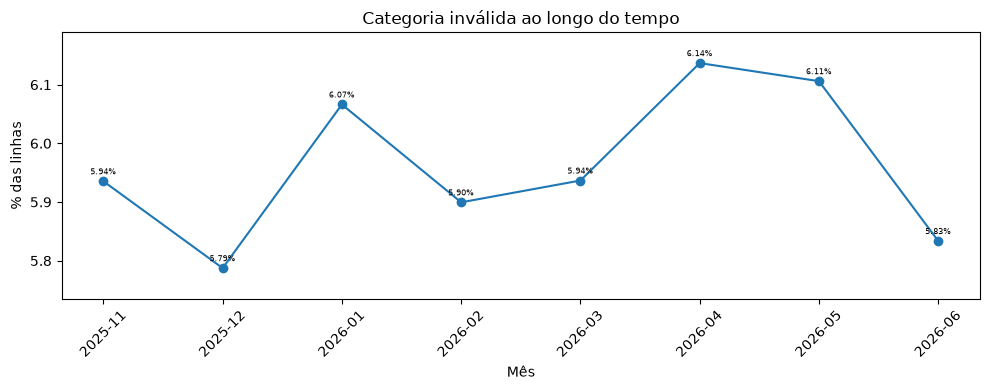

In [81]:
sql_invalid_category_month = f"""
SELECT
  FORMAT_DATE('%Y-%m', DATE(dt_hr_venda)) AS mes,
  COUNT(*) AS linhas,
  COUNTIF(SAFE_CAST(des_categoria_material AS NUMERIC) IS NOT NULL) AS categorias_invalidas,
  SAFE_DIVIDE(
    COUNTIF(SAFE_CAST(des_categoria_material AS NUMERIC) IS NOT NULL),
    COUNT(*)
  ) AS pct_invalida
FROM `{TABLE_ID}`
WHERE {DATE_FILTER}
GROUP BY 1
ORDER BY 1
"""

invalid_category_month = run_bq(
    sql_invalid_category_month,
    "categoria inválida por mês",
)
display(invalid_category_month)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(
    invalid_category_month["mes"],
    invalid_category_month["pct_invalida"] * 100,
    marker="o",
)
for mes, pct in zip(invalid_category_month["mes"], invalid_category_month["pct_invalida"] * 100):
    ax.annotate(f"{pct:.2f}%", (mes, pct), xytext=(0, 5), textcoords="offset points", ha="center", fontsize=6)
ax.margins(y=0.15)
ax.set_title("Categoria inválida ao longo do tempo")
ax.set_xlabel("Mês")
ax.set_ylabel("% das linhas")
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
plt.show()

### 2.3.1 A corrupção se concentra em App ou Site?

Comparamos a taxa de categoria inválida **dentro de cada canal**, além do share dos registros inválidos.

O `lift_vs_global` ajuda a interpretar:

- `1,00`: mesma incidência da base;
- `> 1,00`: incidência acima da média;
- `< 1,00`: incidência abaixo da média.

[BigQuery] categoria inválida por canal | estimativa processada: 2.46 MB


,des_canal_venda_final_agrup,linhas,categorias_invalidas,pct_categoria_invalida,pct_invalida_global,lift_vs_global,share_dos_invalidos
0,App,45936,2758,0.0600,0.0596,1.0068,0.5164
1,Site,43630,2583,0.0592,0.0596,0.9928,0.4836


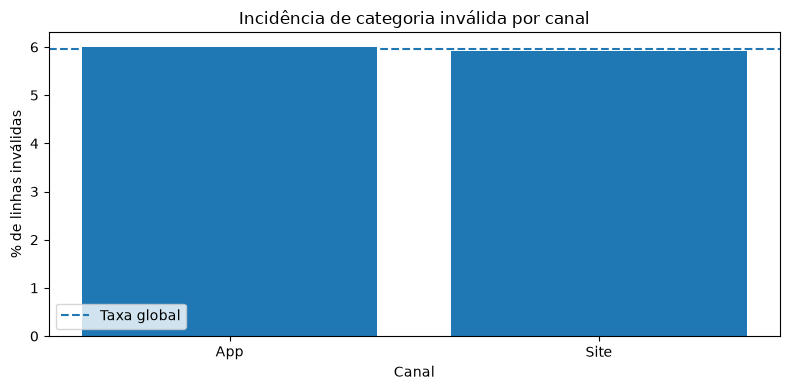

In [82]:
sql_invalid_category_channel = f"""
WITH base AS (
  SELECT
    des_canal_venda_final_agrup,
    SAFE_CAST(des_categoria_material AS NUMERIC) IS NOT NULL
      AS categoria_invalida
  FROM `{TABLE_ID}`
  WHERE {DATE_FILTER}
),
global_rate AS (
  SELECT
    SAFE_DIVIDE(
      COUNTIF(categoria_invalida),
      COUNT(*)
    ) AS pct_invalida_global
  FROM base
),
by_channel AS (
  SELECT
    des_canal_venda_final_agrup,
    COUNT(*) AS linhas,
    COUNTIF(categoria_invalida) AS categorias_invalidas,
    SAFE_DIVIDE(
      COUNTIF(categoria_invalida),
      COUNT(*)
    ) AS pct_categoria_invalida
  FROM base
  GROUP BY 1
)
SELECT
  b.*,
  g.pct_invalida_global,

  SAFE_DIVIDE(
    b.pct_categoria_invalida,
    g.pct_invalida_global
  ) AS lift_vs_global,

  SAFE_DIVIDE(
    b.categorias_invalidas,
    SUM(b.categorias_invalidas) OVER ()
  ) AS share_dos_invalidos

FROM by_channel b
CROSS JOIN global_rate g
ORDER BY pct_categoria_invalida DESC
"""

invalid_category_channel = run_bq(
    sql_invalid_category_channel,
    "categoria inválida por canal",
)
display(invalid_category_channel)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(
    invalid_category_channel["des_canal_venda_final_agrup"],
    invalid_category_channel["pct_categoria_invalida"] * 100,
)
ax.axhline(
    invalid_category_channel["pct_invalida_global"].iloc[0] * 100,
    linestyle="--",
    label="Taxa global",
)
ax.set_title("Incidência de categoria inválida por canal")
ax.set_xlabel("Canal")
ax.set_ylabel("% de linhas inválidas")
ax.legend()
fig.tight_layout()
plt.show()

### 2.3.2 A concentração muda ao longo dos meses?

A taxa mensal é calculada **dentro de cada canal**. Assim evitamos concluir que um canal tem mais problema apenas porque possui mais volume.

[BigQuery] categoria inválida por mês e canal | estimativa processada: 2.46 MB


,mes,des_canal_venda_final_agrup,linhas,categorias_invalidas,pct_categoria_invalida
0,2025-11-01,App,5757,366,0.0636
1,2025-11-01,Site,5666,312,0.0551
2,2025-12-01,App,5900,340,0.0576
3,2025-12-01,Site,5677,330,0.0581
4,2026-01-01,App,5868,357,0.0608
5,2026-01-01,Site,5556,336,0.0605
6,2026-02-01,App,5303,321,0.0605
7,2026-02-01,Site,5020,288,0.0574
8,2026-03-01,App,5894,358,0.0607
9,2026-03-01,Site,5594,324,0.0579


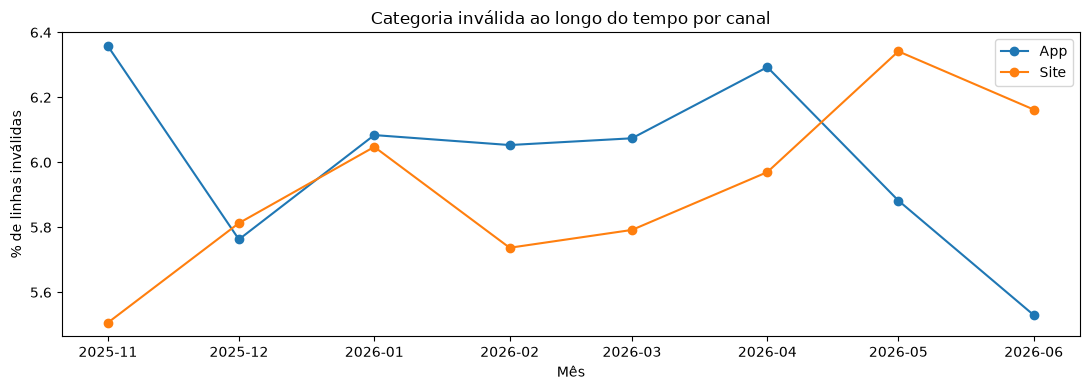

In [83]:
sql_invalid_category_month_channel = f"""
SELECT
  DATE_TRUNC(DATE(dt_hr_venda), MONTH) AS mes,
  des_canal_venda_final_agrup,

  COUNT(*) AS linhas,

  COUNTIF(
    SAFE_CAST(des_categoria_material AS NUMERIC) IS NOT NULL
  ) AS categorias_invalidas,

  SAFE_DIVIDE(
    COUNTIF(
      SAFE_CAST(des_categoria_material AS NUMERIC) IS NOT NULL
    ),
    COUNT(*)
  ) AS pct_categoria_invalida

FROM `{TABLE_ID}`
WHERE {DATE_FILTER}
GROUP BY 1, 2
ORDER BY 1, 2
"""

invalid_category_month_channel = run_bq(
    sql_invalid_category_month_channel,
    "categoria inválida por mês e canal",
)
invalid_category_month_channel["mes"] = pd.to_datetime(
    invalid_category_month_channel["mes"]
)

display(invalid_category_month_channel)

fig, ax = plt.subplots(figsize=(11, 4))

for canal, group in invalid_category_month_channel.groupby("des_canal_venda_final_agrup"):
    ax.plot(
        group["mes"],
        group["pct_categoria_invalida"] * 100,
        marker="o",
        label=canal,
    )

ax.set_title("Categoria inválida ao longo do tempo por canal")
ax.set_xlabel("Mês")
ax.set_ylabel("% de linhas inválidas")
ax.legend()
fig.tight_layout()
plt.show()

### 2.3.3 Quais valores inválidos aparecem em cada canal?

Como a categoria original foi substituída por um valor numérico, **não é possível recuperar qual categoria verdadeira deveria estar ali usando apenas este dataset**.

O que podemos verificar com segurança é se determinados valores inválidos se repetem e se estão concentrados em App ou Site. Isso pode ajudar a localizar a origem do problema no pipeline.

In [84]:
sql_invalid_values_by_channel = f"""
WITH ranked AS (
  SELECT
    des_canal_venda_final_agrup,
    des_categoria_material AS valor_invalido,
    COUNT(*) AS linhas,

    ROW_NUMBER() OVER (
      PARTITION BY des_canal_venda_final_agrup
      ORDER BY COUNT(*) DESC, des_categoria_material
    ) AS rank_canal

  FROM `{TABLE_ID}`
  WHERE {DATE_FILTER}
    AND SAFE_CAST(des_categoria_material AS NUMERIC) IS NOT NULL
  GROUP BY 1, 2
)
SELECT
  des_canal_venda_final_agrup,
  rank_canal,
  valor_invalido,
  linhas
FROM ranked
WHERE rank_canal <= 10
ORDER BY des_canal_venda_final_agrup, rank_canal
"""

invalid_values_by_channel = run_bq(
    sql_invalid_values_by_channel,
    "top valores inválidos por canal",
)

display(invalid_values_by_channel)

[BigQuery] top valores inválidos por canal | estimativa processada: 2.46 MB


,des_canal_venda_final_agrup,rank_canal,valor_invalido,linhas
0,App,1,0.0010040408688505784,1
1,App,2,0.0019208619303319862,1
2,App,3,0.0021335390609045993,1
3,App,4,0.0022656236553724673,1
4,App,5,0.0027613439178184535,1
5,App,6,0.0028674220578636476,1
6,App,7,0.0038429595049671405,1
7,App,8,0.0045236387712643839,1
8,App,9,0.00465820730362276,1
9,App,10,0.0047259230380081877,1


**Conclusão possível:** se App e Site tiverem taxas semelhantes e os mesmos valores inválidos aparecerem nos dois, o problema tende a estar **antes da separação por canal**. Se houver forte concentração em apenas um canal, a investigação deve priorizar a etapa específica daquele fluxo.

### 2.3.4 Existe padrão por hora do dia?

Hora vai de **0 (meia-noite) a 23**. Para cada hora calculamos a **taxa** = linhas com o problema ÷ linhas da hora.

**Como saber se uma diferença é real ou acaso?** Se o problema não depende da hora, cada hora teria a mesma
taxa da base, com uma pequena oscilação aleatória. A **faixa cinza** é essa oscilação esperada (intervalo de
95%: taxa global ± 1,96 × √(p(1−p)/n)). Pontos **vermelhos** ficam fora da faixa.

**Cuidado com comparações múltiplas:** com 24 horas, mesmo sem padrão nenhum espera-se que ~1 hora
(5% de 24) caia fora da faixa por puro acaso. Por isso olhamos também o **teste qui-quadrado**, que avalia as
24 horas de uma vez: p-valor < 0,05 indica que a taxa **varia** com a hora. Um padrão operacional (ex.: carga
ou rotina noturna) apareceria como um **bloco de horas consecutivas** acima da faixa, não como pontos isolados.

[BigQuery] Categoria inválida por hora do dia | estimativa processada: 1.99 MB


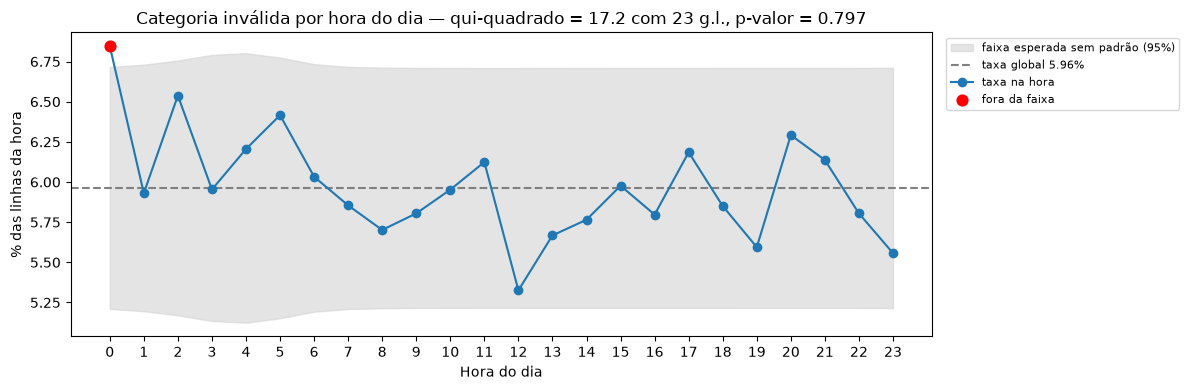

Horas fora da faixa: 1 de 24 (esperado por acaso ≈ 1) -> [0]


,hora,linhas,ocorrencias,taxa,lift_vs_global,fora_da_faixa
0,0,3798,260,0.0685,1.1480,True
1,1,3659,217,0.0593,0.9945,False
2,2,3426,224,0.0654,1.0964,False
3,3,3141,187,0.0595,0.9984,False
4,4,3062,190,0.0621,1.0406,False
5,5,3273,210,0.0642,1.0760,False
6,6,3630,219,0.0603,1.0117,False
7,7,3792,222,0.0585,0.9818,False
8,8,3841,219,0.0570,0.9561,False
9,9,3859,224,0.0580,0.9734,False


In [85]:
def taxa_por_hora(condicao_sql: str, titulo: str) -> pd.DataFrame:
    """Taxa de um problema por hora do dia, faixa de 95% esperada sem padrão e teste qui-quadrado."""
    sql = f"""
    SELECT
      EXTRACT(HOUR FROM dt_hr_venda) AS hora,
      COUNT(*) AS linhas,
      COUNTIF({condicao_sql}) AS ocorrencias
    FROM `{TABLE_ID}`
    WHERE {DATE_FILTER}
    GROUP BY 1
    ORDER BY 1
    """
    tabela = run_bq(sql, titulo)
    taxa_global = tabela["ocorrencias"].sum() / tabela["linhas"].sum()
    tabela["taxa"] = tabela["ocorrencias"] / tabela["linhas"]
    margem = 1.96 * np.sqrt(taxa_global * (1 - taxa_global) / tabela["linhas"])
    tabela["faixa_min"] = taxa_global - margem
    tabela["faixa_max"] = taxa_global + margem
    tabela["fora_da_faixa"] = (tabela["taxa"] < tabela["faixa_min"]) | (tabela["taxa"] > tabela["faixa_max"])
    tabela["lift_vs_global"] = tabela["taxa"] / taxa_global

    # qui-quadrado (tabela 24 horas x [com problema, sem problema])
    esperado = tabela["linhas"] * taxa_global
    qui2 = (((tabela["ocorrencias"] - esperado) ** 2 / esperado)
            + ((tabela["linhas"] - tabela["ocorrencias"] - (tabela["linhas"] - esperado)) ** 2
               / (tabela["linhas"] - esperado))).sum()
    graus = len(tabela) - 1
    try:
        from scipy.stats import chi2
        p_valor = chi2.sf(qui2, graus)
        texto_p = f"p-valor = {p_valor:.3f}"
    except ImportError:
        texto_p = f"(valor crítico a 5% com {graus} g.l. ≈ 35,2)"

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.fill_between(tabela["hora"], tabela["faixa_min"] * 100, tabela["faixa_max"] * 100,
                    color="lightgray", alpha=0.6, label="faixa esperada sem padrão (95%)")
    ax.axhline(taxa_global * 100, color="gray", linestyle="--", label=f"taxa global {taxa_global:.2%}")
    ax.plot(tabela["hora"], tabela["taxa"] * 100, marker="o", label="taxa na hora")
    fora = tabela[tabela["fora_da_faixa"]]
    ax.scatter(fora["hora"], fora["taxa"] * 100, color="red", zorder=3, s=60, label="fora da faixa")
    ax.set_xticks(range(24))
    ax.set_title(f"{titulo} — qui-quadrado = {qui2:.1f} com {graus} g.l., {texto_p}")
    ax.set_xlabel("Hora do dia")
    ax.set_ylabel("% das linhas da hora")
    ax.legend(fontsize=8, loc="upper left", bbox_to_anchor=(1.01, 1))
    fig.tight_layout()
    plt.show()

    print(f"Horas fora da faixa: {int(tabela['fora_da_faixa'].sum())} de 24 "
          f"(esperado por acaso ≈ 1) -> {fora['hora'].tolist()}")
    return tabela


invalid_category_hour = taxa_por_hora(
    "SAFE_CAST(des_categoria_material AS NUMERIC) IS NOT NULL",
    "Categoria inválida por hora do dia",
)
display(invalid_category_hour[["hora", "linhas", "ocorrencias", "taxa", "lift_vs_global", "fora_da_faixa"]])

**Leitura:** se a taxa fica dentro da faixa na maioria das horas e o qui-quadrado não é significativo,
a corrupção da categoria **não depende do horário** — reforça a hipótese de um problema aleatório na geração
ou carga do dado (os valores inválidos também se comportam como números aleatórios entre 0 e 1), e não de uma
rotina operacional em horário específico.

## 2.4 Receita negativa

Receita negativa pode representar estorno, devolução ou ajuste. Sem confirmação de negócio, o comportamento correto é **quantificar e investigar**, não excluir automaticamente.

In [86]:
sql_negative_revenue = f"""
SELECT
  COUNTIF(receita_aprovada < 0) AS linhas_receita_negativa,
  SAFE_DIVIDE(COUNTIF(receita_aprovada < 0), COUNT(*)) AS pct_linhas_negativas,
  CAST(SUM(IF(receita_aprovada < 0, receita_aprovada, 0)) AS FLOAT64) AS receita_negativa_total,
  CAST(SUM(IF(receita_aprovada >= 0, receita_aprovada, 0)) AS FLOAT64) AS receita_nao_negativa_total,
  SAFE_DIVIDE(
    -CAST(SUM(IF(receita_aprovada < 0, receita_aprovada, 0)) AS FLOAT64),
    CAST(SUM(IF(receita_aprovada >= 0, receita_aprovada, 0)) AS FLOAT64)
  ) AS impacto_abs_negativo_sobre_positivo
FROM `{TABLE_ID}`
WHERE {DATE_FILTER}
"""

negative_revenue = run_bq(sql_negative_revenue, "receita negativa")
display(negative_revenue)

[BigQuery] receita negativa | estimativa processada: 2.05 MB


,linhas_receita_negativa,pct_linhas_negativas,receita_negativa_total,receita_nao_negativa_total,impacto_abs_negativo_sobre_positivo
0,3513,0.0392,"-21,051,829.5400","511,361,656.1600",0.0412


### 2.4.1 Existe padrão por canal?

Comparamos a frequência de linhas negativas e o impacto financeiro dentro de cada canal. O objetivo é separar um comportamento sistêmico de algo concentrado em App ou Site.

[BigQuery] receita negativa por canal | estimativa processada: 2.52 MB


,des_canal_venda_final_agrup,linhas,linhas_negativas,pct_linhas_negativas,receita_negativa,receita_positiva,impacto_negativo_sobre_positivo
0,App,45936,1859,0.0405,"-16,197,443.4000","389,670,872.4900",0.0416
1,Site,43630,1654,0.0379,"-4,854,386.1400","121,690,783.6700",0.0399


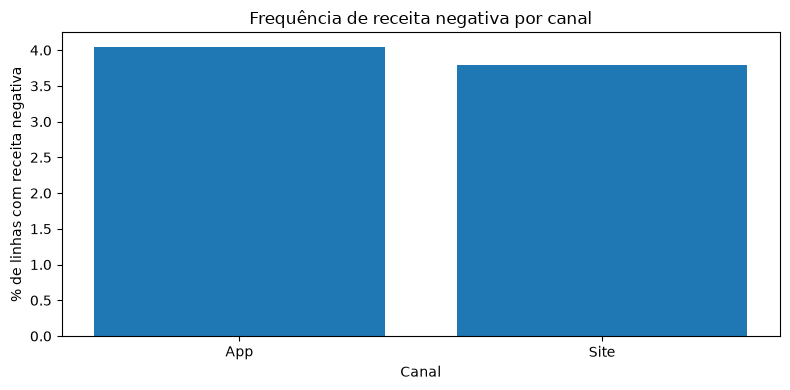

In [87]:
sql_negative_by_channel = f"""
SELECT
  des_canal_venda_final_agrup,
  COUNT(*) AS linhas,
  COUNTIF(receita_aprovada < 0) AS linhas_negativas,
  SAFE_DIVIDE(
    COUNTIF(receita_aprovada < 0),
    COUNT(*)
  ) AS pct_linhas_negativas,

  CAST(SUM(IF(receita_aprovada < 0, receita_aprovada, 0)) AS FLOAT64)
    AS receita_negativa,

  CAST(SUM(IF(receita_aprovada >= 0, receita_aprovada, 0)) AS FLOAT64)
    AS receita_positiva,

  SAFE_DIVIDE(
    -CAST(SUM(IF(receita_aprovada < 0, receita_aprovada, 0)) AS FLOAT64),
    CAST(SUM(IF(receita_aprovada >= 0, receita_aprovada, 0)) AS FLOAT64)
  ) AS impacto_negativo_sobre_positivo

FROM `{TABLE_ID}`
WHERE {DATE_FILTER}
GROUP BY 1
ORDER BY ABS(receita_negativa) DESC
"""

negative_by_channel = run_bq(
    sql_negative_by_channel,
    "receita negativa por canal",
)
display(negative_by_channel)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(
    negative_by_channel["des_canal_venda_final_agrup"],
    negative_by_channel["pct_linhas_negativas"] * 100,
)
ax.set_title("Frequência de receita negativa por canal")
ax.set_xlabel("Canal")
ax.set_ylabel("% de linhas com receita negativa")
fig.tight_layout()
plt.show()

### 2.4.2 Existe padrão por categoria?

Categorias inválidas são agrupadas em `__CATEGORIA_INVALIDA__` para verificar se a corrupção do campo e a receita negativa podem estar relacionadas.

[BigQuery] receita negativa por categoria | estimativa processada: 3.36 MB


,des_categoria_material,linhas,linhas_negativas,pct_linhas_negativas,receita_negativa,receita_positiva,impacto_negativo_sobre_positivo
0,PERFUMARIA FEMININA,10816,425,0.0393,"-5,642,496.0700","125,311,001.2100",0.0450
1,PERFUMARIA MASCULINA,10845,418,0.0385,"-5,087,520.4700","131,825,914.8800",0.0386
2,CORPO E BANHO,10855,404,0.0372,"-2,901,295.4900","74,603,719.8400",0.0389
3,PERF. DE ENTRADA E DEOS,10830,455,0.0420,"-2,081,865.1900","53,247,300.6000",0.0391
4,GIFTS,10513,417,0.0397,"-2,077,178.0100","51,562,388.3100",0.0403
5,__CATEGORIA_INVALIDA__,5341,198,0.0371,"-1,245,101.6100","30,510,019.5600",0.0408
6,CABELOS,10265,418,0.0407,"-813,835.1700","17,262,471.9700",0.0471
7,MAQUIAGEM,10470,410,0.0392,"-805,977.5800","18,088,375.1800",0.0446
8,FACIAL,9631,368,0.0382,"-396,559.9500","8,950,464.6100",0.0443


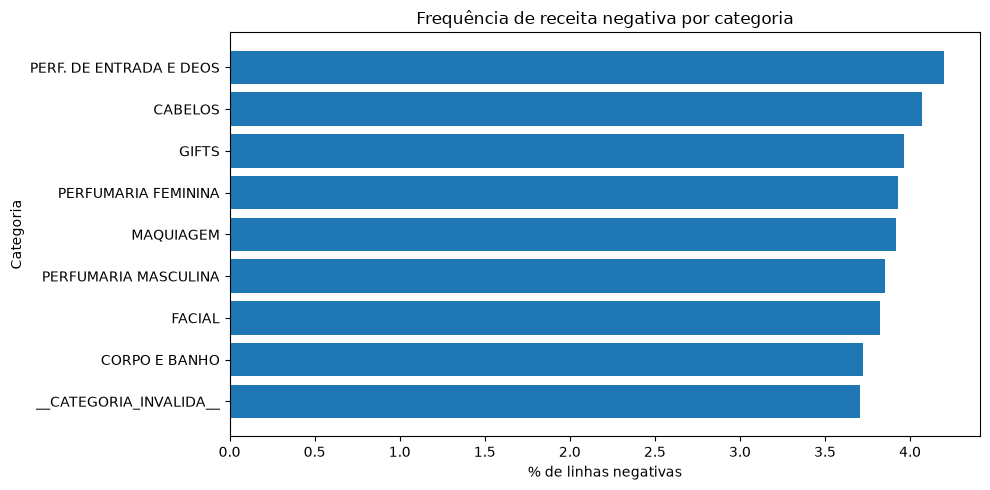

In [88]:
sql_negative_by_category = f"""
WITH base AS (
  SELECT
    IF(
      SAFE_CAST(des_categoria_material AS NUMERIC) IS NOT NULL,
      '__CATEGORIA_INVALIDA__',
      des_categoria_material
    ) AS des_categoria_material,
    receita_aprovada
  FROM `{TABLE_ID}`
  WHERE {DATE_FILTER}
)
SELECT
  des_categoria_material,
  COUNT(*) AS linhas,
  COUNTIF(receita_aprovada < 0) AS linhas_negativas,
  SAFE_DIVIDE(
    COUNTIF(receita_aprovada < 0),
    COUNT(*)
  ) AS pct_linhas_negativas,

  CAST(SUM(IF(receita_aprovada < 0, receita_aprovada, 0)) AS FLOAT64)
    AS receita_negativa,

  CAST(SUM(IF(receita_aprovada >= 0, receita_aprovada, 0)) AS FLOAT64)
    AS receita_positiva,

  SAFE_DIVIDE(
    -CAST(SUM(IF(receita_aprovada < 0, receita_aprovada, 0)) AS FLOAT64),
    CAST(SUM(IF(receita_aprovada >= 0, receita_aprovada, 0)) AS FLOAT64)
  ) AS impacto_negativo_sobre_positivo

FROM base
GROUP BY 1
ORDER BY ABS(receita_negativa) DESC
"""

negative_by_category = run_bq(
    sql_negative_by_category,
    "receita negativa por categoria",
)
display(negative_by_category)

fig, ax = plt.subplots(figsize=(10, 5))
ordered = negative_by_category.sort_values("pct_linhas_negativas")
ax.barh(
    ordered["des_categoria_material"],
    ordered["pct_linhas_negativas"] * 100,
)
ax.set_title("Frequência de receita negativa por categoria")
ax.set_xlabel("% de linhas negativas")
ax.set_ylabel("Categoria")
fig.tight_layout()
plt.show()

### 2.4.3 Categoria × canal — concentração vs. taxa global

Em vez de um heatmap, comparamos cada combinação com a **taxa global de receita negativa**.

- `diferenca_pp`: diferença em pontos percentuais contra a taxa global;
- `lift_vs_global`: taxa do grupo dividida pela taxa global;
- lift ≈ `1,0` indica comportamento próximo ao padrão geral.

Isso evita superinterpretar pequenas diferenças visuais de cor.

In [89]:
sql_negative_category_channel = f"""
WITH base AS (
  SELECT
    IF(
      SAFE_CAST(des_categoria_material AS NUMERIC) IS NOT NULL,
      '__CATEGORIA_INVALIDA__',
      des_categoria_material
    ) AS des_categoria_material,
    des_canal_venda_final_agrup,
    receita_aprovada
  FROM `{TABLE_ID}`
  WHERE {DATE_FILTER}
),
global_rate AS (
  SELECT
    SAFE_DIVIDE(
      COUNTIF(receita_aprovada < 0),
      COUNT(*)
    ) AS pct_negativa_global
  FROM base
),
grouped AS (
  SELECT
    des_categoria_material,
    des_canal_venda_final_agrup,
    COUNT(*) AS linhas,
    COUNTIF(receita_aprovada < 0) AS linhas_negativas,
    SAFE_DIVIDE(
      COUNTIF(receita_aprovada < 0),
      COUNT(*)
    ) AS pct_linhas_negativas,
    CAST(
      SUM(IF(receita_aprovada < 0, receita_aprovada, 0))
      AS FLOAT64
    ) AS receita_negativa
  FROM base
  GROUP BY 1, 2
)
SELECT
  g.*,
  r.pct_negativa_global,
  100 * (g.pct_linhas_negativas - r.pct_negativa_global)
    AS diferenca_pp,
  SAFE_DIVIDE(
    g.pct_linhas_negativas,
    r.pct_negativa_global
  ) AS lift_vs_global,
  SAFE_DIVIDE(
    ABS(g.receita_negativa),
    SUM(ABS(g.receita_negativa)) OVER ()
  ) AS share_valor_negativo
FROM grouped g
CROSS JOIN global_rate r
ORDER BY ABS(g.pct_linhas_negativas - r.pct_negativa_global) DESC
"""

negative_category_channel = run_bq(
    sql_negative_category_channel,
    "receita negativa por categoria x canal",
)

display(
    negative_category_channel[
        [
            "des_categoria_material",
            "des_canal_venda_final_agrup",
            "linhas",
            "linhas_negativas",
            "pct_linhas_negativas",
            "pct_negativa_global",
            "diferenca_pp",
            "lift_vs_global",
            "share_valor_negativo",
        ]
    ]
)

print(
    "Faixa de lift vs. taxa global:",
    f"{negative_category_channel['lift_vs_global'].min():.3f}",
    "a",
    f"{negative_category_channel['lift_vs_global'].max():.3f}",
)

[BigQuery] receita negativa por categoria x canal | estimativa processada: 3.82 MB


,des_categoria_material,des_canal_venda_final_agrup,linhas,linhas_negativas,pct_linhas_negativas,pct_negativa_global,diferenca_pp,lift_vs_global,share_valor_negativo
0,FACIAL,Site,4470,149,0.0333,0.0392,-0.5889,0.8499,0.0034
1,PERFUMARIA MASCULINA,Site,5390,190,0.0353,0.0392,-0.3972,0.8987,0.0555
2,PERF. DE ENTRADA E DEOS,Site,5348,229,0.0428,0.0392,0.3597,1.0917,0.0270
3,__CATEGORIA_INVALIDA__,Site,2583,93,0.0360,0.0392,-0.3218,0.9180,0.0113
4,FACIAL,App,5161,219,0.0424,0.0392,0.3211,1.0819,0.0155
5,PERFUMARIA MASCULINA,App,5455,228,0.0418,0.0392,0.2574,1.0656,0.1862
6,CORPO E BANHO,App,5468,202,0.0369,0.0392,-0.2280,0.9419,0.1105
7,CABELOS,App,5376,223,0.0415,0.0392,0.2258,1.0576,0.0297
8,PERFUMARIA FEMININA,App,5456,225,0.0412,0.0392,0.2017,1.0514,0.2075
9,PERF. DE ENTRADA E DEOS,App,5482,226,0.0412,0.0392,0.2003,1.0511,0.0719


Faixa de lift vs. taxa global: 0.850 a 1.092


### 2.4.4 Quando a receita negativa aparece na linha do tempo?

A análise diária permite distinguir um comportamento recorrente de episódios concentrados. Mostramos tanto a quantidade de linhas negativas quanto o valor negativo absoluto.

[BigQuery] receita negativa na linha do tempo | estimativa processada: 2.05 MB


,data,linhas_negativas,valor_negativo_abs,receita_liquida_dia
27,2025-11-28,18,"641,051.2500","12,707,522.6100"
10,2025-11-11,22,"458,826.8600","6,267,619.5000"
18,2025-11-19,16,"289,235.1300","4,768,614.2000"
17,2025-11-18,14,"283,689.2500","4,158,846.5600"
12,2025-11-13,16,"272,882.7600","3,829,298.4400"
2,2025-11-03,18,"257,618.4800","6,165,950.5600"
5,2025-11-06,19,"257,422.4000","5,735,464.7400"
188,2026-05-08,16,"244,613.3000","4,230,467.1700"
14,2025-11-15,10,"224,391.3600","2,467,078.5400"
4,2025-11-05,25,"218,912.5500","5,286,456.3800"


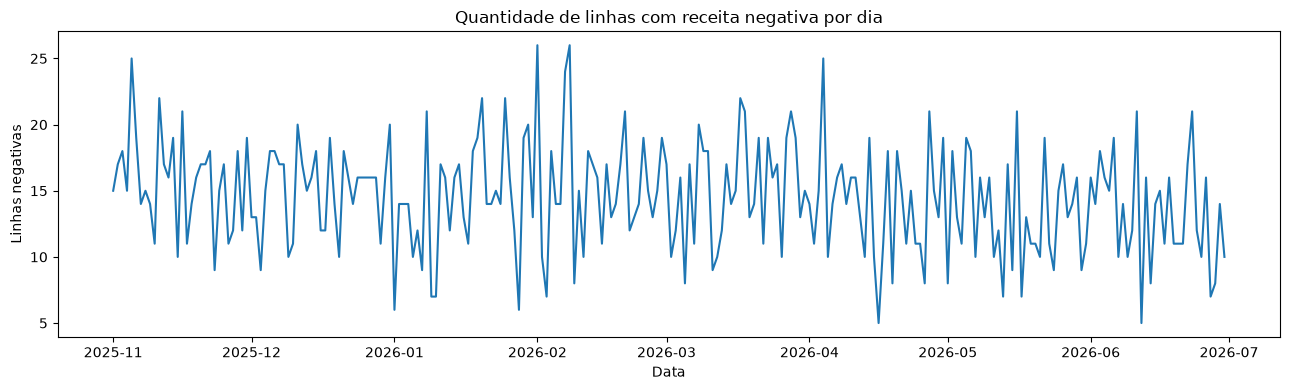

In [90]:
sql_negative_timeline = f"""
SELECT
  DATE(dt_hr_venda) AS data,
  COUNTIF(receita_aprovada < 0) AS linhas_negativas,
  CAST(
    -SUM(IF(receita_aprovada < 0, receita_aprovada, 0))
    AS FLOAT64
  ) AS valor_negativo_abs,
  CAST(SUM(receita_aprovada) AS FLOAT64) AS receita_liquida_dia
FROM `{TABLE_ID}`
WHERE {DATE_FILTER}
GROUP BY 1
ORDER BY 1
"""

negative_timeline = run_bq(
    sql_negative_timeline,
    "receita negativa na linha do tempo",
)
negative_timeline["data"] = pd.to_datetime(negative_timeline["data"])

display(
    negative_timeline.nlargest(10, "valor_negativo_abs")
)

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(
    negative_timeline["data"],
    negative_timeline["linhas_negativas"],
)
ax.set_title("Quantidade de linhas com receita negativa por dia")
ax.set_xlabel("Data")
ax.set_ylabel("Linhas negativas")
fig.tight_layout()
plt.show()

### 2.4.5 Receita negativa ao longo dos meses — normalizada pela receita

O valor absoluto de receita negativa pode ser enganoso: meses de alto volume, como novembro/Black Friday, naturalmente tendem a apresentar valores absolutos maiores.

Por isso, usamos como principal indicador:

`impacto_negativo_pct = |receita negativa| / receita positiva do mês`

Assim medimos o peso relativo dos ajustes negativos independentemente do tamanho do mês.

[BigQuery] receita negativa mensal normalizada | estimativa processada: 2.05 MB


,mes,receita_positiva,receita_negativa_abs,receita_liquida,linhas,linhas_receita_negativa,pct_linhas_receita_negativa,impacto_negativo_pct_receita_positiva
0,2025-11-01,"134,818,940.5700","5,841,561.1000","128,977,379.4700",11423,474,0.0415,0.0433
1,2025-12-01,"66,015,825.5900","2,768,553.5200","63,247,272.0700",11577,469,0.0405,0.0419
2,2026-01-01,"51,480,912.8300","2,053,492.3600","49,427,420.4700",11424,440,0.0385,0.0399
3,2026-02-01,"36,395,530.6900","1,615,349.3300","34,780,181.3600",10323,436,0.0422,0.0444
4,2026-03-01,"54,384,042.7700","2,318,879.4900","52,065,163.2800",11488,473,0.0412,0.0426
5,2026-04-01,"46,032,179.5200","1,750,053.4400","44,282,126.0800",10983,419,0.0381,0.0380
6,2026-05-01,"72,914,675.0400","2,864,708.9000","70,049,966.1400",11497,404,0.0351,0.0393
7,2026-06-01,"49,319,549.1500","1,839,231.4000","47,480,317.7500",10851,398,0.0367,0.0373


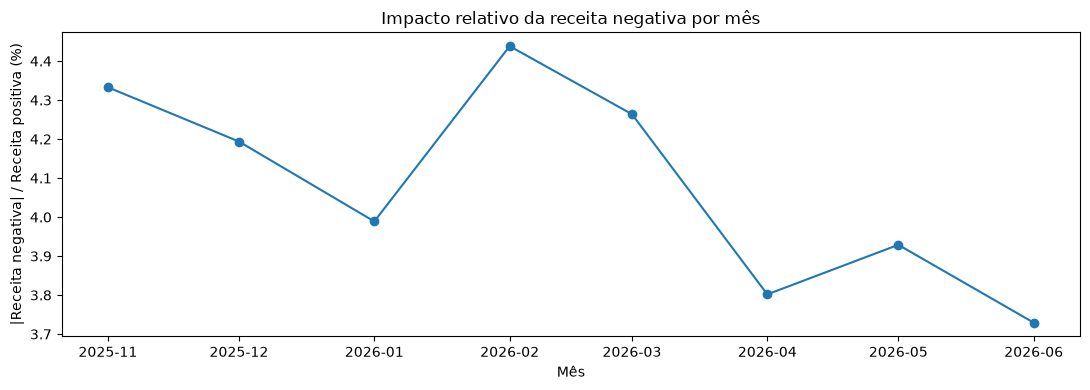

In [91]:
sql_negative_revenue_monthly_ratio = f"""
SELECT
  DATE_TRUNC(DATE(dt_hr_venda), MONTH) AS mes,

  CAST(
    SUM(IF(receita_aprovada > 0, receita_aprovada, 0))
    AS FLOAT64
  ) AS receita_positiva,

  CAST(
    -SUM(IF(receita_aprovada < 0, receita_aprovada, 0))
    AS FLOAT64
  ) AS receita_negativa_abs,

  CAST(
    SUM(receita_aprovada)
    AS FLOAT64
  ) AS receita_liquida,

  COUNT(*) AS linhas,

  COUNTIF(receita_aprovada < 0)
    AS linhas_receita_negativa,

  SAFE_DIVIDE(
    COUNTIF(receita_aprovada < 0),
    COUNT(*)
  ) AS pct_linhas_receita_negativa,

  SAFE_DIVIDE(
    -CAST(
      SUM(IF(receita_aprovada < 0, receita_aprovada, 0))
      AS FLOAT64
    ),
    CAST(
      SUM(IF(receita_aprovada > 0, receita_aprovada, 0))
      AS FLOAT64
    )
  ) AS impacto_negativo_pct_receita_positiva

FROM `{TABLE_ID}`
WHERE {DATE_FILTER}
GROUP BY 1
ORDER BY 1
"""

negative_revenue_monthly_ratio = run_bq(
    sql_negative_revenue_monthly_ratio,
    "receita negativa mensal normalizada",
)

negative_revenue_monthly_ratio["mes"] = pd.to_datetime(
    negative_revenue_monthly_ratio["mes"]
)

display(negative_revenue_monthly_ratio)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(
    negative_revenue_monthly_ratio["mes"],
    negative_revenue_monthly_ratio[
        "impacto_negativo_pct_receita_positiva"
    ] * 100,
    marker="o",
)
ax.set_title("Impacto relativo da receita negativa por mês")
ax.set_xlabel("Mês")
ax.set_ylabel("|Receita negativa| / Receita positiva (%)")
fig.tight_layout()
plt.show()

In [92]:
negative_month_peak = negative_revenue_monthly_ratio.loc[
    negative_revenue_monthly_ratio[
        "impacto_negativo_pct_receita_positiva"
    ].idxmax()
]

print(
    "Maior impacto relativo:",
    negative_month_peak["mes"].strftime("%Y-%m"),
    "|",
    f"{negative_month_peak['impacto_negativo_pct_receita_positiva']:.2%}",
)

display(
    negative_revenue_monthly_ratio.sort_values(
        "impacto_negativo_pct_receita_positiva",
        ascending=False,
    )
)

Maior impacto relativo: 2026-02 | 4.44%


,mes,receita_positiva,receita_negativa_abs,receita_liquida,linhas,linhas_receita_negativa,pct_linhas_receita_negativa,impacto_negativo_pct_receita_positiva
3,2026-02-01,"36,395,530.6900","1,615,349.3300","34,780,181.3600",10323,436,0.0422,0.0444
0,2025-11-01,"134,818,940.5700","5,841,561.1000","128,977,379.4700",11423,474,0.0415,0.0433
4,2026-03-01,"54,384,042.7700","2,318,879.4900","52,065,163.2800",11488,473,0.0412,0.0426
1,2025-12-01,"66,015,825.5900","2,768,553.5200","63,247,272.0700",11577,469,0.0405,0.0419
2,2026-01-01,"51,480,912.8300","2,053,492.3600","49,427,420.4700",11424,440,0.0385,0.0399
6,2026-05-01,"72,914,675.0400","2,864,708.9000","70,049,966.1400",11497,404,0.0351,0.0393
5,2026-04-01,"46,032,179.5200","1,750,053.4400","44,282,126.0800",10983,419,0.0381,0.0380
7,2026-06-01,"49,319,549.1500","1,839,231.4000","47,480,317.7500",10851,398,0.0367,0.0373


**Leitura:** novembro só será considerado mais problemático se o **percentual** de receita negativa também estiver elevado. Se o valor absoluto subir na Black Friday, mas o percentual permanecer estável, isso é compatível com o simples aumento de escala do negócio.

### 2.4.6 Existe padrão por hora do dia?

Mesma metodologia da seção 2.3.4 (taxa por hora, faixa esperada de 95% e qui-quadrado), agora para
`receita_aprovada < 0`. Um padrão operacional real — por exemplo, estornos processados em lote de madrugada —
apareceria como um **bloco de horas consecutivas** acima da faixa.

[BigQuery] Receita negativa por hora do dia | estimativa processada: 2.05 MB


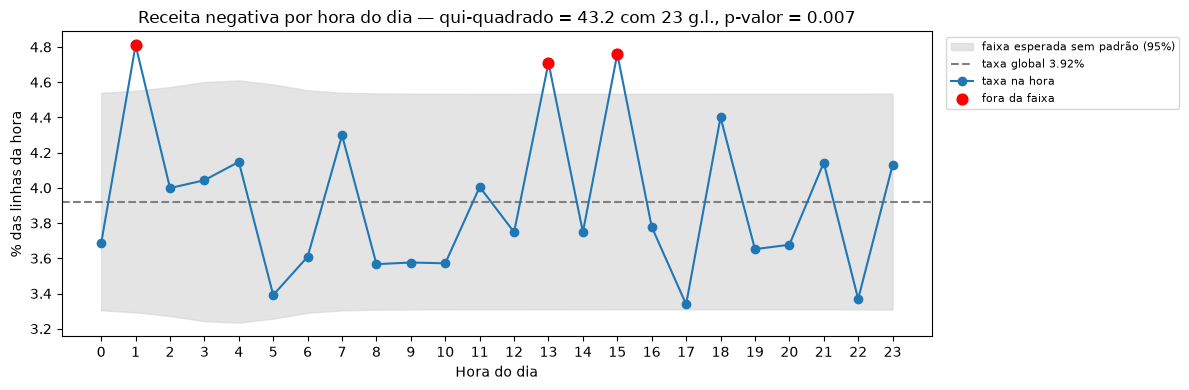

Horas fora da faixa: 3 de 24 (esperado por acaso ≈ 1) -> [1, 13, 15]


,hora,linhas,ocorrencias,taxa,lift_vs_global,fora_da_faixa
0,0,3798,140,0.0369,0.9398,False
1,1,3659,176,0.0481,1.2264,True
2,2,3426,137,0.0400,1.0195,False
3,3,3141,127,0.0404,1.0309,False
4,4,3062,127,0.0415,1.0575,False
5,5,3273,111,0.0339,0.8647,False
6,6,3630,131,0.0361,0.9201,False
7,7,3792,163,0.0430,1.0959,False
8,8,3841,137,0.0357,0.9094,False
9,9,3859,138,0.0358,0.9117,False


In [93]:
negative_revenue_hour = taxa_por_hora(
    "receita_aprovada < 0",
    "Receita negativa por hora do dia",
)
display(negative_revenue_hour[["hora", "linhas", "ocorrencias", "taxa", "lift_vs_global", "fora_da_faixa"]])

**Leitura:** com ~89 mil linhas, o qui-quadrado detecta diferenças pequenas. Por isso a pergunta prática é
dupla: (1) a variação é **estatisticamente** diferente do acaso? (2) ela forma um **padrão de negócio**
(horas consecutivas, horário de rotina)? Diferenças de poucos décimos de ponto percentual em horas
espalhadas, sem continuidade, não sustentam a hipótese de um processo em horário específico.

### 2.4.7 Receita negativa × desconto

Também investigamos se a receita negativa apresenta relação com `vlr_venda_desconto`.

Assumindo que `vlr_venda_desconto` representa o **valor concedido de desconto**, definimos:

`receita_bruta_estimada = receita_aprovada + vlr_venda_desconto`

e, quando o denominador é positivo:

`taxa_desconto = vlr_venda_desconto / receita_bruta_estimada`

A taxa não é calculada quando a receita bruta estimada é menor ou igual a zero, porque nesse caso o percentual perde interpretação econômica.

In [94]:
sql_negative_discount_relation = f"""
WITH base AS (
  SELECT
    receita_aprovada,
    vlr_venda_desconto,
    nr_pedidos,
    qt_material,

    receita_aprovada + vlr_venda_desconto
      AS receita_bruta_estimada,

    CASE
      WHEN vlr_venda_desconto >= 0
       AND receita_aprovada + vlr_venda_desconto > 0
      THEN SAFE_DIVIDE(
        vlr_venda_desconto,
        receita_aprovada + vlr_venda_desconto
      )
    END AS taxa_desconto,

    IF(receita_aprovada < 0, 'NEGATIVA', 'NAO_NEGATIVA')
      AS status_receita

  FROM `{TABLE_ID}`
  WHERE {DATE_FILTER}
)
SELECT
  status_receita,
  COUNT(*) AS linhas,

  COUNTIF(vlr_venda_desconto = 0) AS linhas_sem_desconto,
  COUNTIF(vlr_venda_desconto > 0) AS linhas_com_desconto,
  COUNTIF(vlr_venda_desconto < 0) AS linhas_desconto_negativo,

  COUNTIF(taxa_desconto IS NOT NULL) AS linhas_taxa_valida,

  CAST(AVG(vlr_venda_desconto) AS FLOAT64)
    AS desconto_medio_valor,

  CAST(
    APPROX_QUANTILES(vlr_venda_desconto, 100)[OFFSET(50)]
    AS FLOAT64
  ) AS desconto_mediano_valor,

  AVG(taxa_desconto) AS taxa_desconto_media,

  APPROX_QUANTILES(taxa_desconto, 100 IGNORE NULLS)[OFFSET(50)]
    AS taxa_desconto_mediana,

  APPROX_QUANTILES(taxa_desconto, 100 IGNORE NULLS)[OFFSET(90)]
    AS taxa_desconto_p90,

  SUM(nr_pedidos) AS nr_pedidos,
  SUM(qt_material) AS qt_material

FROM base
GROUP BY 1
ORDER BY 1
"""

negative_discount_relation = run_bq(
    sql_negative_discount_relation,
    "receita negativa x desconto",
)
display(negative_discount_relation)

[BigQuery] receita negativa x desconto | estimativa processada: 4.78 MB


,status_receita,linhas,linhas_sem_desconto,linhas_com_desconto,linhas_desconto_negativo,linhas_taxa_valida,desconto_medio_valor,desconto_mediano_valor,taxa_desconto_media,taxa_desconto_mediana,taxa_desconto_p90,nr_pedidos,qt_material
0,NAO_NEGATIVA,86053,405,85648,0,85987,"4,229.6663","1,041.6500",0.339774326,0.311445201,0.542534687,6254692,9491377
1,NEGATIVA,3513,8,3505,0,497,"4,495.2663","1,058.5300",10.480707553,3.637313191,15.344422290,266203,404824


#### A ocorrência de receita negativa muda quando há desconto?

Primeiro fazemos uma leitura simples de incidência: linhas sem desconto, com desconto e, caso existam, valores de desconto negativos.

In [95]:
sql_negative_by_discount_presence = f"""
WITH base AS (
  SELECT
    receita_aprovada,
    vlr_venda_desconto,

    CASE
      WHEN vlr_venda_desconto < 0 THEN 'DESCONTO_NEGATIVO'
      WHEN vlr_venda_desconto = 0 THEN 'SEM_DESCONTO'
      WHEN vlr_venda_desconto > 0 THEN 'COM_DESCONTO'
      ELSE 'NULO'
    END AS grupo_desconto

  FROM `{TABLE_ID}`
  WHERE {DATE_FILTER}
)
SELECT
  grupo_desconto,
  COUNT(*) AS linhas,
  COUNTIF(receita_aprovada < 0) AS linhas_receita_negativa,

  SAFE_DIVIDE(
    COUNTIF(receita_aprovada < 0),
    COUNT(*)
  ) AS pct_receita_negativa,

  CAST(
    SUM(IF(receita_aprovada < 0, receita_aprovada, 0))
    AS FLOAT64
  ) AS receita_negativa

FROM base
GROUP BY 1
ORDER BY linhas DESC
"""

negative_by_discount_presence = run_bq(
    sql_negative_by_discount_presence,
    "receita negativa por presença de desconto",
)
display(negative_by_discount_presence)

[BigQuery] receita negativa por presença de desconto | estimativa processada: 3.42 MB


,grupo_desconto,linhas,linhas_receita_negativa,pct_receita_negativa,receita_negativa
0,COM_DESCONTO,89153,3505,0.0393,"-21,050,874.7400"
1,SEM_DESCONTO,413,8,0.0194,-954.8000


#### Receita negativa por intensidade de desconto

Para linhas em que a taxa de desconto é economicamente válida, dividimos o histórico em **5 faixas de mesma quantidade de observações**. Isso ajuda a verificar se a incidência de receita negativa cresce conforme aumenta a intensidade do desconto.

[BigQuery] receita negativa por intensidade de desconto | estimativa processada: 3.42 MB


,faixa_desconto,linhas,taxa_min,taxa_media,taxa_max,linhas_receita_negativa,pct_receita_negativa
0,1,17297,0E-9,0.162841393,0.215305571,0,0.0000
1,2,17297,0.215308546,0.248234297,0.280361021,0,0.0000
2,3,17297,0.280373227,0.312954053,0.348035765,0,0.0000
3,4,17297,0.348039983,0.397330437,0.456198286,0,0.0000
4,5,17296,0.456203696,0.868924582,408.128479657,497,0.0287


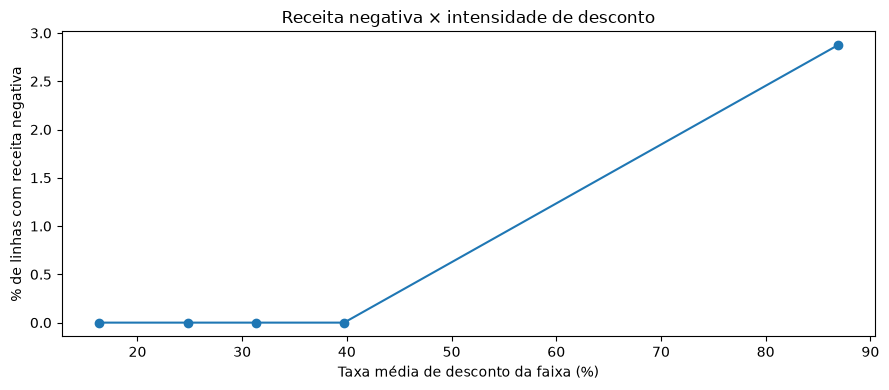

In [96]:
sql_negative_by_discount_bucket = f"""
WITH base AS (
  SELECT
    receita_aprovada,

    CASE
      WHEN vlr_venda_desconto >= 0
       AND receita_aprovada + vlr_venda_desconto > 0
      THEN SAFE_DIVIDE(
        vlr_venda_desconto,
        receita_aprovada + vlr_venda_desconto
      )
    END AS taxa_desconto

  FROM `{TABLE_ID}`
  WHERE {DATE_FILTER}
),
valid AS (
  SELECT *
  FROM base
  WHERE taxa_desconto IS NOT NULL
),
bucketed AS (
  SELECT
    *,
    NTILE(5) OVER (ORDER BY taxa_desconto) AS faixa_desconto
  FROM valid
)
SELECT
  faixa_desconto,
  COUNT(*) AS linhas,
  MIN(taxa_desconto) AS taxa_min,
  AVG(taxa_desconto) AS taxa_media,
  MAX(taxa_desconto) AS taxa_max,

  COUNTIF(receita_aprovada < 0) AS linhas_receita_negativa,

  SAFE_DIVIDE(
    COUNTIF(receita_aprovada < 0),
    COUNT(*)
  ) AS pct_receita_negativa

FROM bucketed
GROUP BY 1
ORDER BY 1
"""

negative_by_discount_bucket = run_bq(
    sql_negative_by_discount_bucket,
    "receita negativa por intensidade de desconto",
)
display(negative_by_discount_bucket)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(
    negative_by_discount_bucket["taxa_media"] * 100,
    negative_by_discount_bucket["pct_receita_negativa"] * 100,
    marker="o",
)
ax.set_title("Receita negativa × intensidade de desconto")
ax.set_xlabel("Taxa média de desconto da faixa (%)")
ax.set_ylabel("% de linhas com receita negativa")
fig.tight_layout()
plt.show()

**Leitura:** se a taxa de receita negativa permanecer aproximadamente estável entre as faixas, desconto provavelmente não explica o fenômeno. Se houver crescimento consistente nas faixas de maior desconto, teremos um sinal para investigação — ainda sem afirmar causalidade.

## 2.5 Cobertura temporal

O dataset deveria cobrir todas as horas entre 01/11/2025 e 30/06/2026. Geramos o calendário esperado no BigQuery e comparamos com o observado.

In [97]:
sql_coverage = f"""
WITH horas_esperadas AS (
  SELECT DATETIME(ts) AS dt_hr_venda
  FROM UNNEST(
    GENERATE_TIMESTAMP_ARRAY(
      TIMESTAMP('{START_DATE} 00:00:00'),
      TIMESTAMP('{END_DATE} 23:00:00'),
      INTERVAL 1 HOUR
    )
  ) AS ts
),
horas_observadas AS (
  SELECT DISTINCT dt_hr_venda
  FROM `{TABLE_ID}`
  WHERE {DATE_FILTER}
),
canais AS (
  SELECT des_canal_venda_final_agrup
  FROM UNNEST(['App', 'Site']) AS des_canal_venda_final_agrup
),
hora_canal_observado AS (
  SELECT DISTINCT
    dt_hr_venda,
    des_canal_venda_final_agrup
  FROM `{TABLE_ID}`
  WHERE {DATE_FILTER}
),
faltas_hora_canal AS (
  SELECT h.dt_hr_venda, c.des_canal_venda_final_agrup
  FROM horas_esperadas h
  CROSS JOIN canais c
  LEFT JOIN hora_canal_observado o
    ON h.dt_hr_venda = o.dt_hr_venda
   AND c.des_canal_venda_final_agrup = o.des_canal_venda_final_agrup
  WHERE o.dt_hr_venda IS NULL
)
SELECT
  (SELECT COUNT(*) FROM horas_esperadas) AS horas_esperadas,
  (
    SELECT COUNT(*)
    FROM horas_esperadas h
    LEFT JOIN horas_observadas o USING (dt_hr_venda)
    WHERE o.dt_hr_venda IS NULL
  ) AS horas_sem_registro,
  (SELECT COUNT(*) FROM faltas_hora_canal) AS combinacoes_hora_canal_ausentes
"""

coverage = run_bq(sql_coverage, "cobertura temporal")
display(coverage)

[BigQuery] cobertura temporal | estimativa processada: 1.15 MB


,horas_esperadas,horas_sem_registro,combinacoes_hora_canal_ausentes
0,5808,0,2


### Combinações hora × canal ausentes

Além da contagem, mostramos as combinações faltantes para entender se são eventos isolados ou um padrão operacional.

In [98]:
sql_missing_hour_channel = f"""
WITH horas_esperadas AS (
  SELECT DATETIME(ts) AS dt_hr_venda
  FROM UNNEST(
    GENERATE_TIMESTAMP_ARRAY(
      TIMESTAMP('{START_DATE} 00:00:00'),
      TIMESTAMP('{END_DATE} 23:00:00'),
      INTERVAL 1 HOUR
    )
  ) AS ts
),
canais AS (
  SELECT des_canal_venda_final_agrup
  FROM UNNEST(['App', 'Site']) AS des_canal_venda_final_agrup
),
observado AS (
  SELECT DISTINCT
    dt_hr_venda,
    des_canal_venda_final_agrup
  FROM `{TABLE_ID}`
  WHERE {DATE_FILTER}
)
SELECT
  h.dt_hr_venda,
  c.des_canal_venda_final_agrup
FROM horas_esperadas h
CROSS JOIN canais c
LEFT JOIN observado o
  ON h.dt_hr_venda = o.dt_hr_venda
 AND c.des_canal_venda_final_agrup = o.des_canal_venda_final_agrup
WHERE o.dt_hr_venda IS NULL
ORDER BY h.dt_hr_venda, c.des_canal_venda_final_agrup
LIMIT 100
"""

missing_hour_channel = run_bq(
    sql_missing_hour_channel,
    "exemplos hora × canal ausentes",
)
display(missing_hour_channel)

print(f"Combinações exibidas: {len(missing_hour_channel)}")

[BigQuery] exemplos hora × canal ausentes | estimativa processada: 1.15 MB


,dt_hr_venda,des_canal_venda_final_agrup
0,2026-04-05 05:00:00,Site
1,2026-06-13 04:00:00,Site


Combinações exibidas: 2


# 3. Analytical EDA — BigQuery agrega, Python visualiza

## 3.1 Série diária para Analytics e Machine Learning

Somente aqui trazemos dados para Pandas: uma tabela diária de aproximadamente 242 linhas, em vez da granularidade horária completa.

### Por que não modelar diretamente no grão horário?

O arquivo horário é valioso e será explorado, mas o **target permanece diário** porque o case solicita previsão de venda diária.

O grão horário pode ser usado a nosso favor para:
- entender o perfil intradiário;
- criar, se necessário, features **históricas** de comportamento horário;
- criar lags por canal/categoria/hora.

Não devemos usar informações do próprio dia realizado para prever esse mesmo dia. Modelar hora a hora e depois somar seria possível, mas adicionaria complexidade sem responder melhor ao objetivo principal do case. A estratégia inicial, portanto, é **forecast diário + enriquecimento com sinais históricos da granularidade horária**.

In [99]:
sql_daily = f"""
SELECT
  DATE(dt_hr_venda) AS data,

  CASE EXTRACT(DAYOFWEEK FROM DATE(dt_hr_venda))
    WHEN 2 THEN 0
    WHEN 3 THEN 1
    WHEN 4 THEN 2
    WHEN 5 THEN 3
    WHEN 6 THEN 4
    WHEN 7 THEN 5
    WHEN 1 THEN 6
  END AS dia_semana_num,

  CASE EXTRACT(DAYOFWEEK FROM DATE(dt_hr_venda))
    WHEN 2 THEN 'Segunda'
    WHEN 3 THEN 'Terça'
    WHEN 4 THEN 'Quarta'
    WHEN 5 THEN 'Quinta'
    WHEN 6 THEN 'Sexta'
    WHEN 7 THEN 'Sábado'
    WHEN 1 THEN 'Domingo'
  END AS dia_semana,

  FORMAT_DATE('%Y-%m', DATE(dt_hr_venda)) AS mes,
  EXTRACT(MONTH FROM DATE(dt_hr_venda)) AS mes_num,
  EXTRACT(YEAR FROM DATE(dt_hr_venda)) AS ano,
  EXTRACT(ISOWEEK FROM DATE(dt_hr_venda)) AS semana_ano,
  EXTRACT(ISOYEAR FROM DATE(dt_hr_venda)) AS ano_iso,
  DATE_TRUNC(DATE(dt_hr_venda), WEEK(MONDAY)) AS semana_inicio,
  IF(EXTRACT(DAYOFWEEK FROM DATE(dt_hr_venda)) IN (1, 7), 1, 0) AS fim_de_semana,

  CAST(SUM(receita_aprovada) AS FLOAT64) AS receita_aprovada,
  SUM(nr_pedidos) AS nr_pedidos,
  SUM(qt_material) AS qt_material,
  CAST(SUM(vlr_venda_desconto) AS FLOAT64) AS vlr_venda_desconto,

  SAFE_DIVIDE(
    CAST(SUM(receita_aprovada) AS FLOAT64),
    SUM(qt_material)
  ) AS preco_medio_item,

  SAFE_DIVIDE(
    CAST(SUM(receita_aprovada) AS FLOAT64),
    SUM(nr_pedidos)
  ) AS ticket_medio,

  SAFE_DIVIDE(
    SUM(qt_material),
    SUM(nr_pedidos)
  ) AS itens_por_pedido,

  SAFE_DIVIDE(
    CAST(SUM(vlr_venda_desconto) AS FLOAT64),
    CAST(SUM(receita_aprovada + vlr_venda_desconto) AS FLOAT64)
  ) AS taxa_desconto

FROM `{TABLE_ID}`
WHERE {DATE_FILTER}
GROUP BY ALL
ORDER BY 1
"""

daily = run_bq(sql_daily, "agregação diária")
daily["data"] = pd.to_datetime(daily["data"])

print(f"Linhas trazidas para Pandas: {len(daily)}")
display(daily.head())
display(
    daily[
        [
            "receita_aprovada",
            "nr_pedidos",
            "qt_material",
            "vlr_venda_desconto",
            "taxa_desconto",
            "preco_medio_item",
            "ticket_medio",
            "itens_por_pedido",
        ]
    ].describe(percentiles=[0.01, 0.05, 0.50, 0.95, 0.99]).T
)

[BigQuery] agregação diária | estimativa processada: 4.78 MB
Linhas trazidas para Pandas: 242


,data,dia_semana_num,dia_semana,mes,mes_num,ano,semana_ano,ano_iso,semana_inicio,fim_de_semana,receita_aprovada,nr_pedidos,qt_material,vlr_venda_desconto,preco_medio_item,ticket_medio,itens_por_pedido,taxa_desconto
0,2025-11-01,5,Sábado,2025-11,11,2025,44,2025,2025-10-27,1,"1,726,330.8700",19347,27265,"1,068,230.0800",63.3167,89.2299,1.4093,0.3823
1,2025-11-02,6,Domingo,2025-11,11,2025,44,2025,2025-10-27,1,"1,944,052.5700",23668,36328,"1,656,038.4300",53.5139,82.1384,1.5349,0.4600
2,2025-11-03,0,Segunda,2025-11,11,2025,45,2025,2025-11-03,0,"6,165,950.5600",93066,148539,"8,539,908.1600",41.5107,66.2535,1.5961,0.5807
3,2025-11-04,1,Terça,2025-11,11,2025,45,2025,2025-11-03,0,"4,923,643.7800",80728,125065,"6,447,197.4600",39.3687,60.9905,1.5492,0.5670
4,2025-11-05,2,Quarta,2025-11,11,2025,45,2025,2025-11-03,0,"5,286,456.3800",94316,151324,"7,142,309.1400",34.9347,56.0505,1.6044,0.5747


,count,mean,std,min,1%,5%,50%,95%,99%,max
receita_aprovada,242.0000,"2,026,073.6637","1,262,137.3326","618,877.6800","768,213.6194","977,218.3075","1,692,029.7450","4,236,459.2380","6,383,015.5999","12,707,522.6100"
nr_pedidos,242.0000,"26,945.8471","24,154.4979","6,718.0000","7,210.6400","10,455.0500","19,916.0000","72,598.8000","112,920.0600","251,986.0000"
qt_material,242.0000,"40,893.3926","40,617.2974","9,090.0000","10,223.3000","14,914.4500","28,956.5000","120,074.9500","192,228.1900","422,860.0000"
vlr_venda_desconto,242.0000,"1,569,286.5404","1,832,156.9427","192,754.6700","243,596.4424","394,019.1020","1,043,355.1400","5,112,070.1875","8,263,758.5862","17,444,767.1200"
taxa_desconto,242.0000,0.3859,0.0925,0.2144,0.2243,0.2501,0.3787,0.5563,0.5804,0.5868
preco_medio_item,242.0000,56.9502,13.0434,29.0770,29.8999,34.8342,56.5462,76.3872,93.7876,100.0286
ticket_medio,242.0000,82.6509,14.4836,50.1818,50.4755,57.3318,82.7907,106.1485,119.2144,123.0793
itens_por_pedido,242.0000,1.4734,0.1322,1.2100,1.2556,1.3227,1.4336,1.7179,1.9490,2.0541


### Evolução da demanda

`qt_material` é a melhor proxy disponível para demanda operacional em unidades.

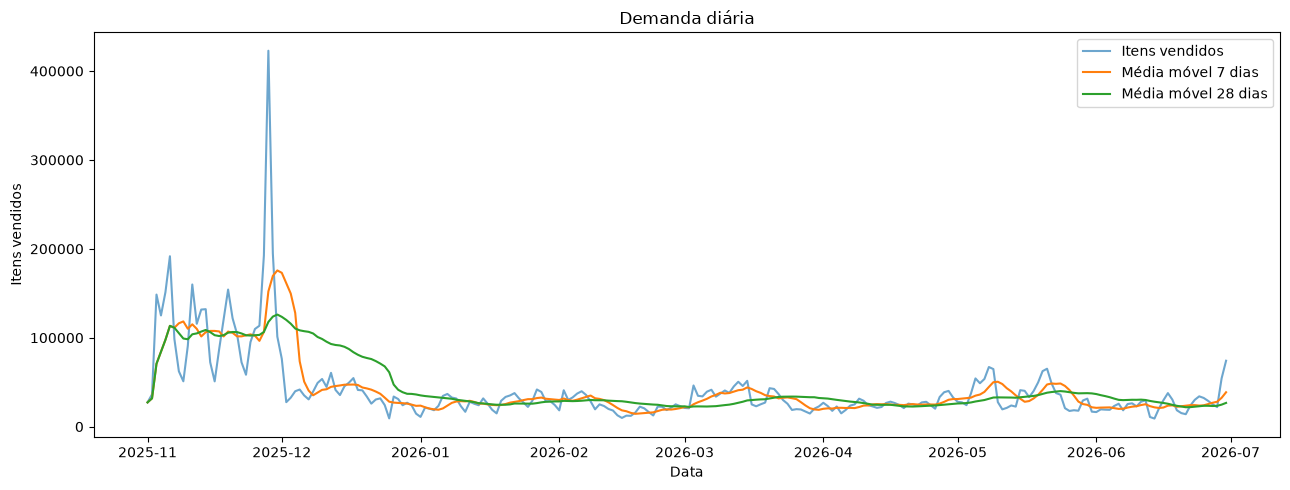

In [100]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(daily["data"], daily["qt_material"], label="Itens vendidos", alpha=0.65)
ax.plot(
    daily["data"],
    daily["qt_material"].rolling(7, min_periods=1).mean(),
    label="Média móvel 7 dias",
)
ax.plot(
    daily["data"],
    daily["qt_material"].rolling(28, min_periods=1).mean(),
    label="Média móvel 28 dias",
)
ax.set_title("Demanda diária")
ax.set_xlabel("Data")
ax.set_ylabel("Itens vendidos")
ax.legend()
fig.tight_layout()
plt.show()

### Baseline imediato: médias móveis de 7 e 28 dias

As médias móveis do gráfico acima são descritivas. Para tratá-las como **previsões**, precisamos deslocá-las um dia para trás, garantindo que a previsão de *t* use apenas informação disponível até *t-1*.

Usamos uma janela comum após 28 dias para comparar os dois baselines de forma justa. A métrica principal é **WAPE**. Também mostramos `1 - WAPE` como uma leitura percentual intuitiva, mas ela não substitui as métricas formais do modelo.

,modelo,MAE,WAPE,1-WAPE,Bias
0,Média móvel 7 dias,"11,110.1656",0.3603,0.6397,0.0943
1,Média móvel 28 dias,"15,631.8139",0.5070,0.4930,0.2222


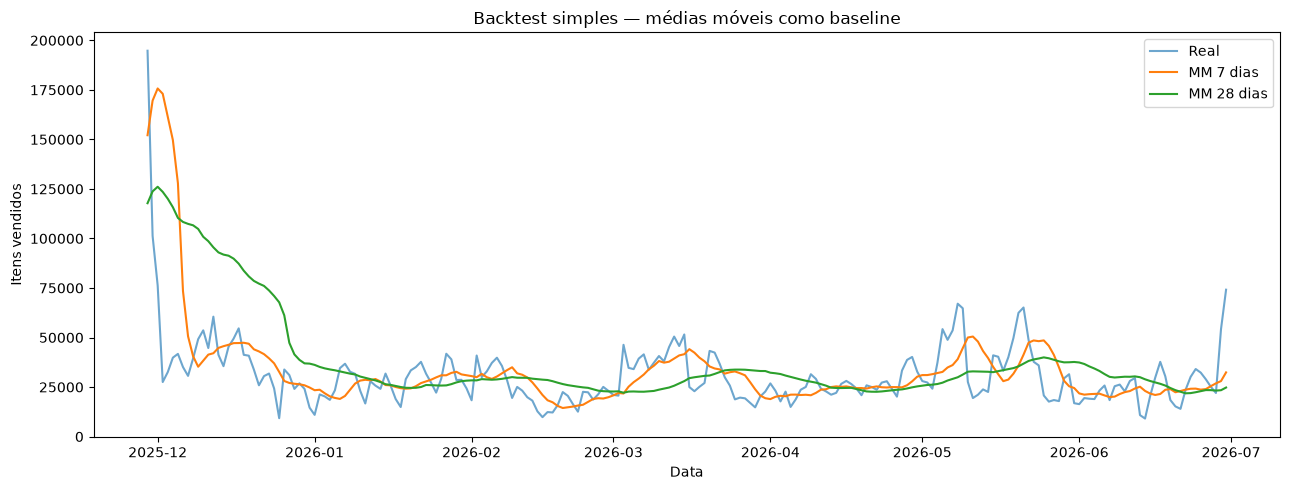

In [101]:
baseline = daily[["data", "qt_material"]].copy()

baseline["pred_media_movel_7"] = (
    baseline["qt_material"]
    .shift(1)
    .rolling(7, min_periods=7)
    .mean()
)

baseline["pred_media_movel_28"] = (
    baseline["qt_material"]
    .shift(1)
    .rolling(28, min_periods=28)
    .mean()
)

evaluation = baseline.dropna(
    subset=["pred_media_movel_7", "pred_media_movel_28"]
).copy()

def forecast_metrics(y_true, y_pred):
    error = y_pred - y_true
    abs_error = np.abs(error)

    mae = abs_error.mean()
    wape = abs_error.sum() / np.abs(y_true).sum()
    bias = error.sum() / y_true.sum()

    return {
        "MAE": mae,
        "WAPE": wape,
        "1-WAPE": 1 - wape,
        "Bias": bias,
    }

baseline_metrics = pd.DataFrame([
    {
        "modelo": "Média móvel 7 dias",
        **forecast_metrics(
            evaluation["qt_material"],
            evaluation["pred_media_movel_7"],
        ),
    },
    {
        "modelo": "Média móvel 28 dias",
        **forecast_metrics(
            evaluation["qt_material"],
            evaluation["pred_media_movel_28"],
        ),
    },
])

display(baseline_metrics)

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(evaluation["data"], evaluation["qt_material"], label="Real", alpha=0.65)
ax.plot(evaluation["data"], evaluation["pred_media_movel_7"], label="MM 7 dias")
ax.plot(evaluation["data"], evaluation["pred_media_movel_28"], label="MM 28 dias")
ax.set_title("Backtest simples — médias móveis como baseline")
ax.set_xlabel("Data")
ax.set_ylabel("Itens vendidos")
ax.legend()
fig.tight_layout()
plt.show()

## 3.2 Extremos de negócio — nível diário total

Aqui usamos IQR no **total diário do e-commerce** para identificar dias extraordinários que o modelo de forecast terá de compreender.

Esta análise **não é uma regra de Data Quality** e não implica remoção. Um pico simultâneo de itens, pedidos e receita pode ser um evento comercial perfeitamente legítimo.

[BigQuery] limites de outliers | estimativa processada: 3.42 MB


,q1_itens,q3_itens,q1_pedidos,q3_pedidos,q1_receita,q3_receita,li_itens,ls_itens,li_pedidos,ls_pedidos,li_receita,ls_receita,dias_outlier_itens,dias_outlier_pedidos,dias_outlier_receita
0,22519,40919,15124,28133,"1,351,056.1500","2,245,633.4300","-5,081.0000","68,519.0000","-4,389.5000","47,646.5000","9,190.2300","3,587,499.3500",26,25,25


C:\Users\guiso\AppData\Local\Temp\ipykernel_22228\1965501894.py:71: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[0].boxplot(daily["qt_material"], vert=False)
C:\Users\guiso\AppData\Local\Temp\ipykernel_22228\1965501894.py:75: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(daily["nr_pedidos"], vert=False)
C:\Users\guiso\AppData\Local\Temp\ipykernel_22228\1965501894.py:79: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[2].boxplot(daily["receita_aprovada"], vert=False)


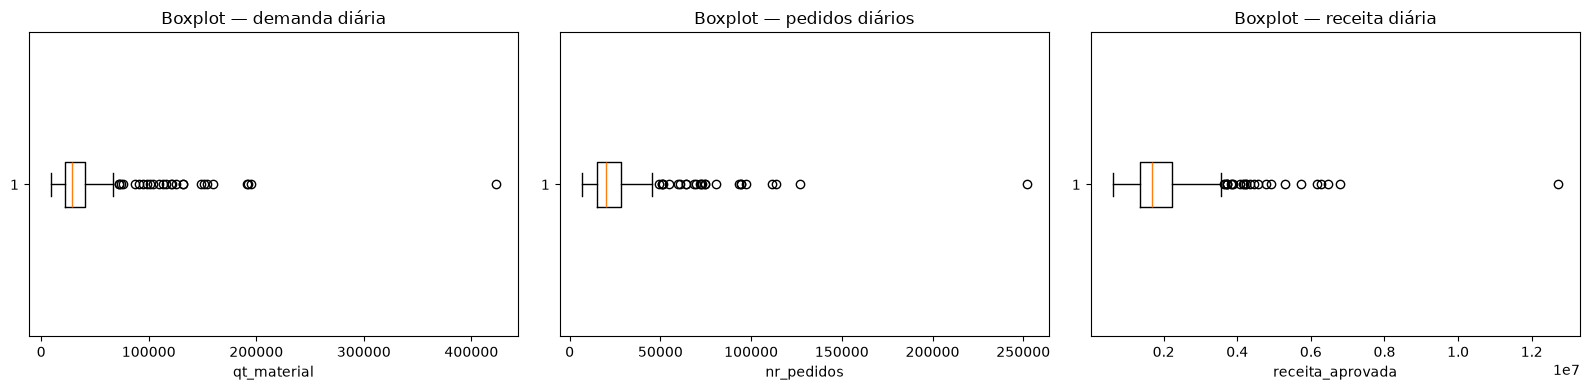

,metrica,dias
0,Outlier de itens,26
1,Outlier de pedidos,25
2,Outlier de receita,25
3,Itens + pedidos,23
4,Itens sem pedidos,3
5,Pedidos sem itens,2
6,Itens + pedidos + receita,22


,data,qt_material,nr_pedidos,receita_aprovada,itens_por_pedido,outlier_itens,outlier_pedidos,outlier_receita
27,2025-11-28,422860,251986,"12,707,522.6100",1.6781,True,True,True
28,2025-11-29,194761,126711,"6,783,608.8600",1.5370,True,True,True
26,2025-11-27,192614,111484,"6,463,206.1100",1.7277,True,True,True
5,2025-11-06,191673,113918,"5,735,464.7400",1.6826,True,True,True
10,2025-11-11,159901,97447,"6,267,619.5000",1.6409,True,True,True
18,2025-11-19,154178,94350,"4,768,614.2000",1.6341,True,True,True
4,2025-11-05,151324,94316,"5,286,456.3800",1.6044,True,True,True
2,2025-11-03,148539,93066,"6,165,950.5600",1.5961,True,True,True
13,2025-11-14,132129,72915,"3,882,949.2200",1.8121,True,True,True
12,2025-11-13,131695,74445,"3,829,298.4400",1.7690,True,True,True


In [102]:
sql_daily_outliers = f"""
WITH daily AS (
  SELECT
    DATE(dt_hr_venda) AS data,
    SUM(qt_material) AS qt_material,
    SUM(nr_pedidos) AS nr_pedidos,
    CAST(SUM(receita_aprovada) AS FLOAT64) AS receita_aprovada
  FROM `{TABLE_ID}`
  WHERE {DATE_FILTER}
  GROUP BY 1
),
quartis AS (
  SELECT
    APPROX_QUANTILES(qt_material, 100)[OFFSET(25)] AS q1_itens,
    APPROX_QUANTILES(qt_material, 100)[OFFSET(75)] AS q3_itens,

    APPROX_QUANTILES(nr_pedidos, 100)[OFFSET(25)] AS q1_pedidos,
    APPROX_QUANTILES(nr_pedidos, 100)[OFFSET(75)] AS q3_pedidos,

    APPROX_QUANTILES(receita_aprovada, 100)[OFFSET(25)] AS q1_receita,
    APPROX_QUANTILES(receita_aprovada, 100)[OFFSET(75)] AS q3_receita
  FROM daily
),
limites AS (
  SELECT
    *,
    q1_itens - 1.5 * (q3_itens - q1_itens) AS li_itens,
    q3_itens + 1.5 * (q3_itens - q1_itens) AS ls_itens,

    q1_pedidos - 1.5 * (q3_pedidos - q1_pedidos) AS li_pedidos,
    q3_pedidos + 1.5 * (q3_pedidos - q1_pedidos) AS ls_pedidos,

    q1_receita - 1.5 * (q3_receita - q1_receita) AS li_receita,
    q3_receita + 1.5 * (q3_receita - q1_receita) AS ls_receita
  FROM quartis
)
SELECT
  l.*,

  COUNTIF(
    d.qt_material < l.li_itens
    OR d.qt_material > l.ls_itens
  ) AS dias_outlier_itens,

  COUNTIF(
    d.nr_pedidos < l.li_pedidos
    OR d.nr_pedidos > l.ls_pedidos
  ) AS dias_outlier_pedidos,

  COUNTIF(
    d.receita_aprovada < l.li_receita
    OR d.receita_aprovada > l.ls_receita
  ) AS dias_outlier_receita

FROM daily d
CROSS JOIN limites l
GROUP BY
  q1_itens, q3_itens,
  q1_pedidos, q3_pedidos,
  q1_receita, q3_receita,
  li_itens, ls_itens,
  li_pedidos, ls_pedidos,
  li_receita, ls_receita
"""

outlier_limits = run_bq(sql_daily_outliers, "limites de outliers")
display(outlier_limits)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].boxplot(daily["qt_material"], vert=False)
axes[0].set_title("Boxplot — demanda diária")
axes[0].set_xlabel("qt_material")

axes[1].boxplot(daily["nr_pedidos"], vert=False)
axes[1].set_title("Boxplot — pedidos diários")
axes[1].set_xlabel("nr_pedidos")

axes[2].boxplot(daily["receita_aprovada"], vert=False)
axes[2].set_title("Boxplot — receita diária")
axes[2].set_xlabel("receita_aprovada")

fig.tight_layout()
plt.show()

# Diagnóstico complementar: os mesmos picos aparecem em itens e pedidos?
daily_outlier_flags = daily[[
    "data",
    "qt_material",
    "nr_pedidos",
    "receita_aprovada",
    "itens_por_pedido",
]].copy()

limits = outlier_limits.iloc[0]

daily_outlier_flags["outlier_itens"] = (
    (daily_outlier_flags["qt_material"] < limits["li_itens"])
    | (daily_outlier_flags["qt_material"] > limits["ls_itens"])
)
daily_outlier_flags["outlier_pedidos"] = (
    (daily_outlier_flags["nr_pedidos"] < limits["li_pedidos"])
    | (daily_outlier_flags["nr_pedidos"] > limits["ls_pedidos"])
)
daily_outlier_flags["outlier_receita"] = (
    (daily_outlier_flags["receita_aprovada"] < limits["li_receita"])
    | (daily_outlier_flags["receita_aprovada"] > limits["ls_receita"])
)

outlier_overlap = pd.DataFrame({
    "metrica": [
        "Outlier de itens",
        "Outlier de pedidos",
        "Outlier de receita",
        "Itens + pedidos",
        "Itens sem pedidos",
        "Pedidos sem itens",
        "Itens + pedidos + receita",
    ],
    "dias": [
        int(daily_outlier_flags["outlier_itens"].sum()),
        int(daily_outlier_flags["outlier_pedidos"].sum()),
        int(daily_outlier_flags["outlier_receita"].sum()),
        int((daily_outlier_flags["outlier_itens"] & daily_outlier_flags["outlier_pedidos"]).sum()),
        int((daily_outlier_flags["outlier_itens"] & ~daily_outlier_flags["outlier_pedidos"]).sum()),
        int((~daily_outlier_flags["outlier_itens"] & daily_outlier_flags["outlier_pedidos"]).sum()),
        int((
            daily_outlier_flags["outlier_itens"]
            & daily_outlier_flags["outlier_pedidos"]
            & daily_outlier_flags["outlier_receita"]
        ).sum()),
    ],
})

display(outlier_overlap)

display(
    daily_outlier_flags[
        daily_outlier_flags[
            ["outlier_itens", "outlier_pedidos", "outlier_receita"]
        ].any(axis=1)
    ].sort_values("qt_material", ascending=False)
)

### Como interpretar estes boxplots

- **Caixa:** vai de Q1 (25% dos dias abaixo) até Q3 (75% dos dias abaixo). Portanto contém os 50% centrais da distribuição.
- **Linha laranja dentro da caixa:** mediana, isto é, metade dos dias abaixo e metade acima.
- **Bigodes:** chegam até a observação mais extrema que ainda esteja dentro dos limites de Tukey.
- **Círculos fora dos bigodes:** dias sinalizados como outliers estatísticos. Cada círculo é um dia.

Pelos limites calculados acima para a demanda: Q1 = **22.519 itens**, Q3 = **40.919 itens** e limite superior ≈ **68.519 itens**. Como o limite inferior é negativo (≈ -5.081), ele não é relevante para uma quantidade vendida não negativa. Assim, os **26 pontos** de demanda sinalizados são essencialmente dias acima de ~68,5 mil itens.

Para receita: Q1 ≈ **R$ 1,35 mi**, Q3 ≈ **R$ 2,25 mi** e limite superior ≈ **R$ 3,59 mi**. Existem **25 dias** sinalizados. A grande concentração de pontos à direita indica uma distribuição assimétrica, típica de e-commerce com campanhas e datas comerciais.

**Importante:** o ponto muito distante à direita não deve ser removido automaticamente. Ele representa um dia real que precisa ser confrontado com calendário comercial/campanhas.

### Por que olhar pedidos também?

Um dia extremo em `qt_material` pode ter duas explicações diferentes: **mais pedidos** ou **mais itens por pedido**. Ao cruzar outliers de `qt_material` com `nr_pedidos` e observar `itens_por_pedido`, conseguimos distinguir um pico de tráfego/conversão de uma mudança no tamanho da cesta.


### 3.2.1 Extremos por categoria × canal — itens vendidos

O boxplot anterior olha o e-commerce como um todo. Agora repetimos a regra de Tukey **dentro de cada categoria × canal**, porque segmentos com escalas diferentes não devem compartilhar o mesmo limite.

Para cada segmento com **mais de 20 dias observados**:

- Q1 = percentil 25%;
- Q3 = percentil 75%;
- IQR = Q3 − Q1;
- limite inferior = Q1 − 1,5 × IQR;
- limite superior = Q3 + 1,5 × IQR.

A análise abaixo considera somente `qt_material`. O objetivo é responder **quando** ocorreu um extremo e **quanto** ele ultrapassou o comportamento esperado do próprio segmento.

Categorias numéricas inválidas são excluídas deste corte porque já foram tratadas separadamente como problema de qualidade.

In [103]:
sql_segment_outliers_itens = f"""
WITH daily_segment AS (
  SELECT
    DATE(dt_hr_venda) AS data,
    des_categoria_material,
    des_canal_venda_final_agrup,
    SUM(qt_material) AS qt_material
  FROM `{TABLE_ID}`
  WHERE {DATE_FILTER}
    AND SAFE_CAST(des_categoria_material AS NUMERIC) IS NULL
  GROUP BY 1, 2, 3
),
stats AS (
  SELECT
    *,
    COUNT(*) OVER (
      PARTITION BY des_categoria_material, des_canal_venda_final_agrup
    ) AS n_dias,

    PERCENTILE_CONT(qt_material, 0.25) OVER (
      PARTITION BY des_categoria_material, des_canal_venda_final_agrup
    ) AS q1_itens,

    PERCENTILE_CONT(qt_material, 0.75) OVER (
      PARTITION BY des_categoria_material, des_canal_venda_final_agrup
    ) AS q3_itens

  FROM daily_segment
),
limits AS (
  SELECT
    *,
    q3_itens - q1_itens AS iqr_itens,
    q1_itens - 1.5 * (q3_itens - q1_itens) AS limite_inferior,
    q3_itens + 1.5 * (q3_itens - q1_itens) AS limite_superior
  FROM stats
  WHERE n_dias > 20
),
outliers AS (
  SELECT
    *,
    CASE
      WHEN qt_material > limite_superior THEN 'ACIMA'
      WHEN qt_material < limite_inferior THEN 'ABAIXO'
    END AS direcao,

    CASE
      WHEN qt_material > limite_superior
        THEN qt_material - limite_superior
      WHEN qt_material < limite_inferior
        THEN limite_inferior - qt_material
    END AS excesso_itens,

    CASE
      WHEN qt_material > limite_superior
        THEN SAFE_DIVIDE(
          qt_material - limite_superior,
          ABS(limite_superior)
        )
      WHEN qt_material < limite_inferior
        THEN SAFE_DIVIDE(
          limite_inferior - qt_material,
          ABS(limite_inferior)
        )
    END AS excesso_pct_limite

  FROM limits
  WHERE
    qt_material > limite_superior
    OR qt_material < limite_inferior
)
SELECT
  data,
  des_categoria_material,
  des_canal_venda_final_agrup,
  n_dias,
  qt_material,
  q1_itens,
  q3_itens,
  iqr_itens,
  limite_inferior,
  limite_superior,
  direcao,
  excesso_itens,
  excesso_pct_limite
FROM outliers
ORDER BY excesso_pct_limite DESC, excesso_itens DESC
"""

segment_outliers_itens = run_bq(
    sql_segment_outliers_itens,
    "outliers de itens por categoria x canal",
)

segment_outliers_itens["data"] = pd.to_datetime(
    segment_outliers_itens["data"]
)

print(
    f"Extremos encontrados: {len(segment_outliers_itens):,}"
    f"  (detalhe por dia em `segment_outliers_itens`; abaixo, só o resumo por segmento)"
)

[BigQuery] outliers de itens por categoria x canal | estimativa processada: 3.14 MB
Extremos encontrados: 376  (detalhe por dia em `segment_outliers_itens`; abaixo, só o resumo por segmento)


#### Resumo por segmento

A tabela abaixo mostra **quantos dias extremos** cada combinação apresentou. Ela não indica erro: mede apenas a frequência de dias que excederam os limites do próprio histórico.

In [104]:
segment_outlier_summary = (
    segment_outliers_itens
    .groupby(["des_categoria_material", "des_canal_venda_final_agrup"], as_index=False)
    .agg(
        n_dias=("n_dias", "max"),
        dias_outlier=("data", "nunique"),
        maior_excesso_itens=("excesso_itens", "max"),
        maior_excesso_pct=("excesso_pct_limite", "max"),
        primeiro_extremo=("data", "min"),
        ultimo_extremo=("data", "max"),
    )
)

segment_outlier_summary["pct_dias_outlier"] = (
    segment_outlier_summary["dias_outlier"]
    / segment_outlier_summary["n_dias"]
)

segment_outlier_summary = segment_outlier_summary.sort_values(
    ["pct_dias_outlier", "maior_excesso_pct"],
    ascending=False,
)

display(segment_outlier_summary)

,des_categoria_material,des_canal_venda_final_agrup,n_dias,dias_outlier,maior_excesso_itens,maior_excesso_pct,primeiro_extremo,ultimo_extremo,pct_dias_outlier
4,FACIAL,App,242,42,"26,721.0000",12.3537,2025-11-03,2026-05-22,0.1736
8,MAQUIAGEM,App,242,34,"31,599.7500",10.5500,2025-11-02,2026-06-17,0.1405
5,FACIAL,Site,242,33,"7,861.6250",15.9021,2025-11-03,2026-05-22,0.1364
0,CABELOS,App,242,27,"16,185.5000",5.2920,2025-11-03,2026-06-17,0.1116
15,PERFUMARIA MASCULINA,Site,242,25,"25,542.8750",8.6407,2025-11-03,2026-06-30,0.1033
1,CABELOS,Site,242,25,"4,303.3750",5.1132,2025-11-03,2025-12-01,0.1033
3,CORPO E BANHO,Site,242,25,"17,510.3750",4.9992,2025-11-05,2026-05-09,0.1033
9,MAQUIAGEM,Site,242,22,"11,609.0000",11.9067,2025-11-02,2026-05-21,0.0909
12,PERFUMARIA FEMININA,App,242,22,"45,649.2500",2.7498,2025-11-03,2025-12-12,0.0909
10,PERF. DE ENTRADA E DEOS,App,242,22,"13,671.7500",2.0633,2025-11-06,2026-05-09,0.0909


#### Leitura

Um registro como:

`PERFUMARIA FEMININA | App | 80.000 itens | limite superior 35.000 | excesso 45.000`

significa que naquele dia o segmento vendeu **45 mil itens acima do limite de Tukey calculado a partir do seu próprio histórico**.

Esse resultado continua sendo um **extremo estatístico**, não um erro. O próximo passo é confrontar os maiores excessos com contexto comercial — especialmente Black Friday — antes de decidir qualquer tratamento.

[BigQuery] top 10 dias + calendário comercial | estimativa processada: 3.42 MB


,data,qt_material,nr_pedidos,receita_aprovada,preco_medio_item,evento_proximo
0,2025-11-28,422860,251986,"12,707,522.6100",30.0514,Black Friday (0d)
1,2025-11-29,194761,126711,"6,783,608.8600",34.8304,Black Friday (1d)
2,2025-11-27,192614,111484,"6,463,206.1100",33.5552,Black Friday (-1d)
3,2025-11-06,191673,113918,"5,735,464.7400",29.9232,NaN
4,2025-11-11,159901,97447,"6,267,619.5000",39.1969,NaN
5,2025-11-19,154178,94350,"4,768,614.2000",30.9293,NaN
6,2025-11-05,151324,94316,"5,286,456.3800",34.9347,NaN
7,2025-11-03,148539,93066,"6,165,950.5600",41.5107,NaN
8,2025-11-14,132129,72915,"3,882,949.2200",29.3876,NaN
9,2025-11-13,131695,74445,"3,829,298.4400",29.0770,NaN


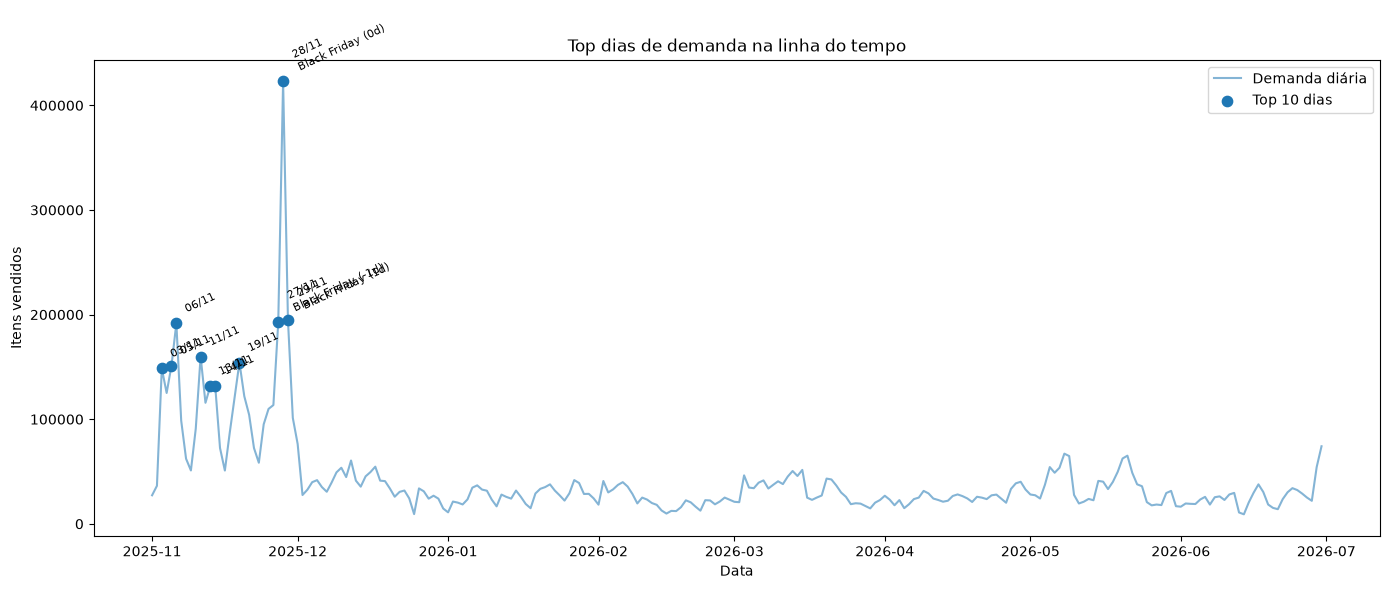

In [105]:
sql_top_days = f"""
WITH calendario_comercial AS (
  SELECT *
  FROM UNNEST([
    STRUCT(DATE '2025-11-28' AS data_evento, 'Black Friday' AS evento)
  ])
),
daily AS (
  SELECT
    DATE(dt_hr_venda) AS data,
    SUM(qt_material) AS qt_material,
    SUM(nr_pedidos) AS nr_pedidos,
    CAST(SUM(receita_aprovada) AS FLOAT64) AS receita_aprovada,
    SAFE_DIVIDE(
      CAST(SUM(receita_aprovada) AS FLOAT64),
      SUM(qt_material)
    ) AS preco_medio_item
  FROM `{TABLE_ID}`
  WHERE {DATE_FILTER}
  GROUP BY 1
),
top_days AS (
  SELECT *
  FROM daily
  ORDER BY qt_material DESC
  LIMIT 10
)
SELECT
  t.*,
  ARRAY_TO_STRING(
    ARRAY_AGG(
      IF(
        ABS(DATE_DIFF(t.data, c.data_evento, DAY)) <= 3,
        CONCAT(
          c.evento,
          ' (',
          CAST(DATE_DIFF(t.data, c.data_evento, DAY) AS STRING),
          'd)'
        ),
        NULL
      )
      IGNORE NULLS
    ),
    ', '
  ) AS evento_proximo
FROM top_days t
LEFT JOIN calendario_comercial c
  ON ABS(DATE_DIFF(t.data, c.data_evento, DAY)) <= 3
GROUP BY
  t.data,
  t.qt_material,
  t.nr_pedidos,
  t.receita_aprovada,
  t.preco_medio_item
ORDER BY t.qt_material DESC
"""

top_days = run_bq(sql_top_days, "top 10 dias + calendário comercial")
top_days["data"] = pd.to_datetime(top_days["data"])
display(top_days)

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(daily["data"], daily["qt_material"], alpha=0.55, label="Demanda diária")
ax.scatter(
    top_days["data"],
    top_days["qt_material"],
    s=55,
    label="Top 10 dias",
    zorder=3,
)

for _, row in top_days.iterrows():
    label = row["data"].strftime("%d/%m")
    if pd.notna(row["evento_proximo"]) and row["evento_proximo"]:
        label += f"\n{row['evento_proximo']}"

    ax.annotate(
        label,
        (row["data"], row["qt_material"]),
        xytext=(5, 8),
        textcoords="offset points",
        fontsize=8,
        rotation=25,
    )

ax.set_title("Top dias de demanda na linha do tempo")
ax.set_xlabel("Data")
ax.set_ylabel("Itens vendidos")
ax.legend()
fig.tight_layout()
plt.show()

O calendário comercial acima é uma **camada contextual de apoio**. Para este case mantemos apenas **Black Friday**, por ser o evento comercial que queremos testar explicitamente contra os maiores picos observados.

Em produção, eventos comerciais deveriam vir de uma dimensão/calendário versionada, e não ficar hardcoded no notebook.

# 4. Insights pedidos no enunciado

## 4.1 Preço médio de venda

Usamos média **ponderada**: `SUM(receita_aprovada) / SUM(qt_material)`. Uma média simples dos preços médios por linha daria o mesmo peso a volumes muito diferentes.

In [106]:
sql_kpis = f"""
SELECT
  CAST(SUM(receita_aprovada) AS FLOAT64) AS receita_total,
  SUM(nr_pedidos) AS nr_pedidos,
  SUM(qt_material) AS qt_material,
  SAFE_DIVIDE(CAST(SUM(receita_aprovada) AS FLOAT64), SUM(qt_material)) AS preco_medio_item,
  SAFE_DIVIDE(CAST(SUM(receita_aprovada) AS FLOAT64), SUM(nr_pedidos)) AS ticket_medio,
  SAFE_DIVIDE(SUM(qt_material), SUM(nr_pedidos)) AS itens_por_pedido
FROM `{TABLE_ID}`
WHERE {DATE_FILTER}
"""

kpis = run_bq(sql_kpis, "KPIs gerais")
display(kpis)

[BigQuery] KPIs gerais | estimativa processada: 3.42 MB


,receita_total,nr_pedidos,qt_material,preco_medio_item,ticket_medio,itens_por_pedido
0,"490,309,826.6200",6520895,9896201,49.5453,75.1906,1.5176


### Por canal

In [107]:
sql_channel = f"""
SELECT
  des_canal_venda_final_agrup,
  CAST(SUM(receita_aprovada) AS FLOAT64) AS receita_aprovada,
  SUM(nr_pedidos) AS nr_pedidos,
  SUM(qt_material) AS qt_material,
  SAFE_DIVIDE(CAST(SUM(receita_aprovada) AS FLOAT64), SUM(qt_material)) AS preco_medio_item,
  SAFE_DIVIDE(CAST(SUM(receita_aprovada) AS FLOAT64), SUM(nr_pedidos)) AS ticket_medio,
  SAFE_DIVIDE(
    CAST(SUM(receita_aprovada) AS FLOAT64),
    SUM(CAST(SUM(receita_aprovada) AS FLOAT64)) OVER ()
  ) AS share_receita
FROM `{TABLE_ID}`
WHERE {DATE_FILTER}
GROUP BY 1
ORDER BY receita_aprovada DESC
"""

channel = run_bq(sql_channel, "KPIs por canal")
display(channel)

[BigQuery] KPIs por canal | estimativa processada: 3.89 MB


,des_canal_venda_final_agrup,receita_aprovada,nr_pedidos,qt_material,preco_medio_item,ticket_medio,share_receita
0,App,"373,473,429.0900",5088139,7727618,48.3297,73.4008,0.7617
1,Site,"116,836,397.5300",1432756,2168583,53.8768,81.5466,0.2383


### Por categoria válida

[BigQuery] KPIs por categoria | estimativa processada: 4.72 MB


,des_categoria_material,receita_aprovada,nr_pedidos,qt_material,preco_medio_item,ticket_medio,share_receita
0,PERFUMARIA MASCULINA,"126,738,394.4100",1161579,1691222,74.9389,109.1087,0.2749
1,PERFUMARIA FEMININA,"119,668,505.1400",1448905,2136959,55.9994,82.5924,0.2596
2,CORPO E BANHO,"71,702,424.3500",1281907,2113614,33.9241,55.9342,0.1555
3,PERF. DE ENTRADA E DEOS,"51,165,435.4100",820181,1209788,42.2929,62.3831,0.1110
4,GIFTS,"49,485,210.3000",390875,475554,104.0580,126.6011,0.1073
5,MAQUIAGEM,"17,282,397.6000",399524,587234,29.4302,43.2575,0.0375
6,CABELOS,"16,448,636.8000",313113,656521,25.0542,52.5326,0.0357
7,FACIAL,"8,553,904.6600",322449,441687,19.3664,26.5279,0.0186


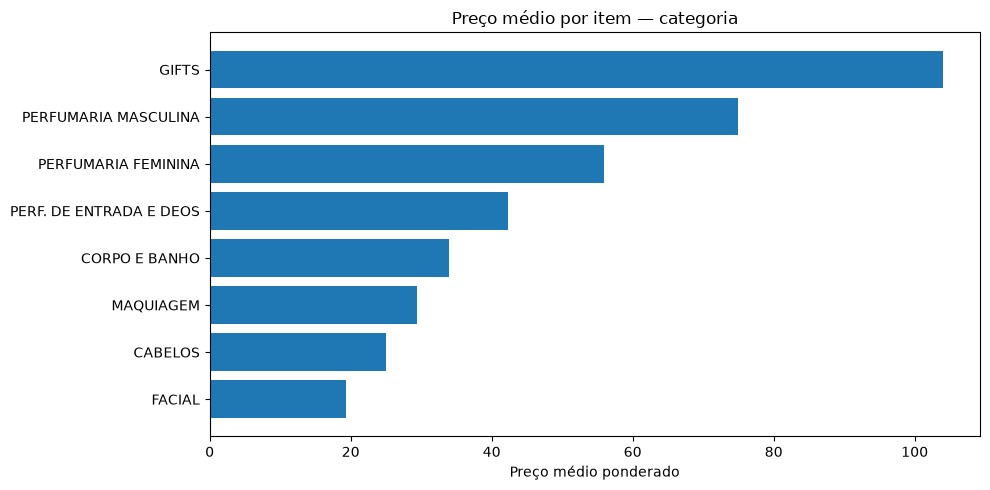

In [108]:
sql_category = f"""
SELECT
  des_categoria_material,
  CAST(SUM(receita_aprovada) AS FLOAT64) AS receita_aprovada,
  SUM(nr_pedidos) AS nr_pedidos,
  SUM(qt_material) AS qt_material,
  SAFE_DIVIDE(CAST(SUM(receita_aprovada) AS FLOAT64), SUM(qt_material)) AS preco_medio_item,
  SAFE_DIVIDE(CAST(SUM(receita_aprovada) AS FLOAT64), SUM(nr_pedidos)) AS ticket_medio,
  SAFE_DIVIDE(
    CAST(SUM(receita_aprovada) AS FLOAT64),
    SUM(CAST(SUM(receita_aprovada) AS FLOAT64)) OVER ()
  ) AS share_receita
FROM `{TABLE_ID}`
WHERE {DATE_FILTER}
  AND SAFE_CAST(des_categoria_material AS NUMERIC) IS NULL
GROUP BY 1
ORDER BY receita_aprovada DESC
"""

category = run_bq(sql_category, "KPIs por categoria")
display(category)

fig, ax = plt.subplots(figsize=(10, 5))
ordered = category.sort_values("preco_medio_item")
ax.barh(ordered["des_categoria_material"], ordered["preco_medio_item"])
ax.set_title("Preço médio por item — categoria")
ax.set_xlabel("Preço médio ponderado")
fig.tight_layout()
plt.show()

### Evolução mensal

[BigQuery] KPIs mensais | estimativa processada: 3.42 MB


,mes,receita_aprovada,nr_pedidos,qt_material,preco_medio_item,dias,demanda_media_diaria
0,2025-11,"128,977,379.4700",2195142,3594101,35.8859,30,"119,803.3667"
1,2025-12,"63,247,272.0700",788342,1149448,55.0240,31,"37,078.9677"
2,2026-01,"49,427,420.4700",582782,846794,58.3701,31,"27,315.9355"
3,2026-02,"34,780,181.3600",447018,636831,54.6145,28,"22,743.9643"
4,2026-03,"52,065,163.2800",668712,990497,52.5647,31,"31,951.5161"
5,2026-04,"44,282,126.0800",533778,768725,57.6046,30,"25,624.1667"
6,2026-05,"70,049,966.1400",793220,1126422,62.1880,31,"36,336.1935"
7,2026-06,"47,480,317.7500",511901,783383,60.6093,30,"26,112.7667"


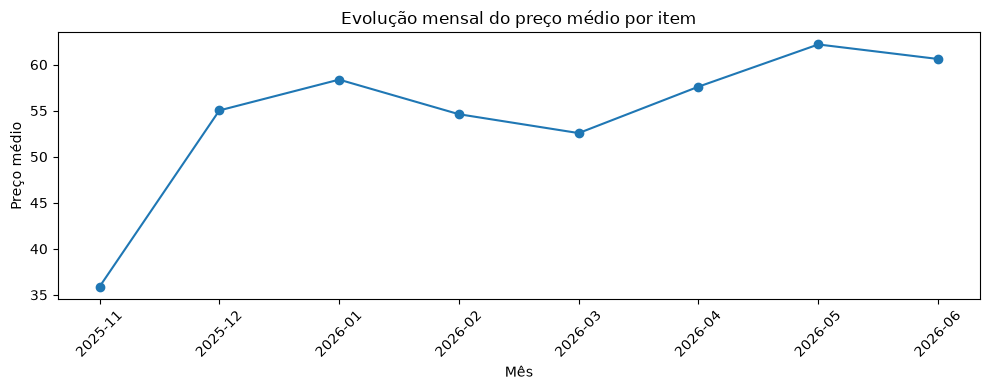

In [109]:
sql_monthly = f"""
SELECT
  FORMAT_DATE('%Y-%m', DATE(dt_hr_venda)) AS mes,
  CAST(SUM(receita_aprovada) AS FLOAT64) AS receita_aprovada,
  SUM(nr_pedidos) AS nr_pedidos,
  SUM(qt_material) AS qt_material,
  SAFE_DIVIDE(CAST(SUM(receita_aprovada) AS FLOAT64), SUM(qt_material)) AS preco_medio_item,
  COUNT(DISTINCT DATE(dt_hr_venda)) AS dias,
  SAFE_DIVIDE(SUM(qt_material), COUNT(DISTINCT DATE(dt_hr_venda))) AS demanda_media_diaria
FROM `{TABLE_ID}`
WHERE {DATE_FILTER}
GROUP BY 1
ORDER BY 1
"""

monthly = run_bq(sql_monthly, "KPIs mensais")
display(monthly)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(monthly["mes"], monthly["preco_medio_item"], marker="o")
ax.set_title("Evolução mensal do preço médio por item")
ax.set_xlabel("Mês")
ax.set_ylabel("Preço médio")
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
plt.show()

### 4.1.1 Participação mensal das categorias

Com apenas **8 categorias válidas**, rankings de "Top N" são triviais (todas aparecem em todos os meses).
O que interessa é o **peso relativo** de cada categoria na demanda de cada mês: o heatmap mostra quais
categorias ganham ou perdem relevância ao longo do período — por exemplo, em novembro (Black Friday) e
maio (Dia das Mães).

[BigQuery] share mensal por categoria | estimativa processada: 2.67 MB


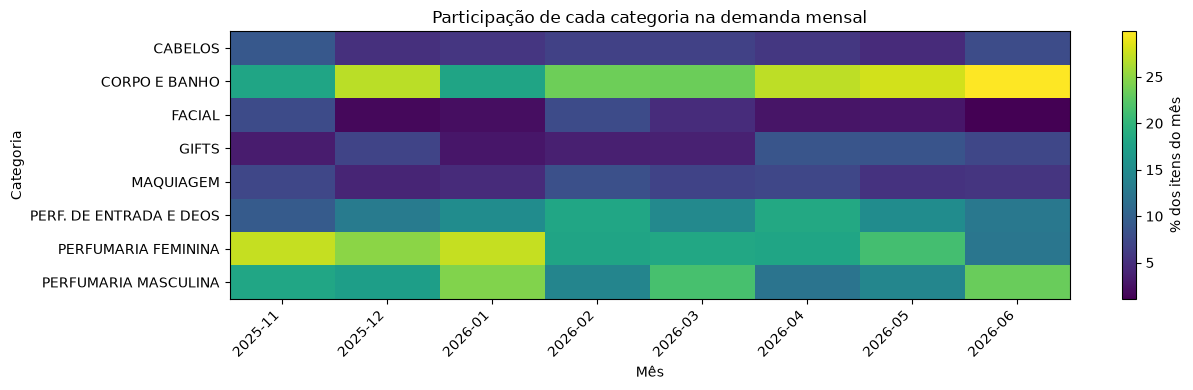

In [110]:
sql_category_month_share = f"""
WITH base AS (
  SELECT
    DATE_TRUNC(DATE(dt_hr_venda), MONTH) AS mes,
    des_categoria_material,
    SUM(qt_material) AS qt_material
  FROM `{TABLE_ID}`
  WHERE {DATE_FILTER}
    AND SAFE_CAST(des_categoria_material AS NUMERIC) IS NULL
  GROUP BY 1, 2
)
SELECT
  mes,
  des_categoria_material,
  qt_material,
  SAFE_DIVIDE(
    qt_material,
    SUM(qt_material) OVER (PARTITION BY mes)
  ) AS share_itens_mes
FROM base
ORDER BY mes, share_itens_mes DESC
"""

category_month_share = run_bq(
    sql_category_month_share,
    "share mensal por categoria",
)
category_month_share["mes"] = pd.to_datetime(category_month_share["mes"])

heat_category = (
    category_month_share
    .pivot(
        index="des_categoria_material",
        columns="mes",
        values="share_itens_mes",
    )
    .fillna(0)
)

fig, ax = plt.subplots(figsize=(13, max(4, len(heat_category) * 0.45)))
image = ax.imshow(
    heat_category.to_numpy() * 100,
    aspect="auto",
)

ax.set_title("Participação de cada categoria na demanda mensal")
ax.set_xlabel("Mês")
ax.set_ylabel("Categoria")
ax.set_xticks(range(len(heat_category.columns)))
ax.set_xticklabels(
    [d.strftime("%Y-%m") for d in heat_category.columns],
    rotation=45,
    ha="right",
)
ax.set_yticks(range(len(heat_category.index)))
ax.set_yticklabels(heat_category.index)

cbar = fig.colorbar(image, ax=ax)
cbar.set_label("% dos itens do mês")

fig.tight_layout()
plt.show()

## 4.2 Desconto como KPI — volume × monetização

Agora saímos da pergunta de Data Quality e analisamos desconto como **alavanca de negócio**.

Queremos testar no histórico se dias com maior taxa de desconto estão associados a:

- maior número de pedidos;
- maior quantidade de itens;
- menor preço médio por item;
- menor ticket médio;
- maior ou menor receita total.

A análise é feita no **grão diário**, evitando interpretar cada linha horária/categoria como uma observação independente.

### Correlação de Spearman com a taxa de desconto

Spearman mede associação monotônica e é menos sensível a caudas longas do que Pearson.

Valores próximos de:
- `+1`: a métrica tende a aumentar quando o desconto aumenta;
- `-1`: tende a diminuir;
- `0`: sem associação monotônica clara.

In [111]:
discount_corr_columns = [
    "taxa_desconto",
    "nr_pedidos",
    "qt_material",
    "receita_aprovada",
    "preco_medio_item",
    "ticket_medio",
    "itens_por_pedido",
]

discount_corr = (
    daily[discount_corr_columns]
    .corr(method="spearman")
    .loc["taxa_desconto"]
    .drop("taxa_desconto")
    .rename("spearman_vs_taxa_desconto")
    .sort_values(ascending=False)
    .to_frame()
)

display(discount_corr)

,spearman_vs_taxa_desconto
qt_material,0.7050
itens_por_pedido,0.6603
nr_pedidos,0.6417
receita_aprovada,0.5285
ticket_medio,-0.6302
preco_medio_item,-0.6975


### Cinco níveis de intensidade promocional

Agrupamos os dias em quintis de taxa de desconto. Isso torna a leitura mais executiva: em vez de olhar centenas de pontos, comparamos dias de **menor** até **maior intensidade de desconto**.

In [112]:
sql_discount_quintiles = f"""
WITH daily AS (
  SELECT
    DATE(dt_hr_venda) AS data,

    CAST(SUM(receita_aprovada) AS FLOAT64)
      AS receita_aprovada,

    CAST(SUM(vlr_venda_desconto) AS FLOAT64)
      AS vlr_venda_desconto,

    SUM(nr_pedidos) AS nr_pedidos,
    SUM(qt_material) AS qt_material,

    SAFE_DIVIDE(
      CAST(SUM(vlr_venda_desconto) AS FLOAT64),
      CAST(
        SUM(receita_aprovada + vlr_venda_desconto)
        AS FLOAT64
      )
    ) AS taxa_desconto,

    SAFE_DIVIDE(
      CAST(SUM(receita_aprovada) AS FLOAT64),
      SUM(qt_material)
    ) AS preco_medio_item,

    SAFE_DIVIDE(
      CAST(SUM(receita_aprovada) AS FLOAT64),
      SUM(nr_pedidos)
    ) AS ticket_medio

  FROM `{TABLE_ID}`
  WHERE {DATE_FILTER}
  GROUP BY 1
),
valid AS (
  SELECT *
  FROM daily
  WHERE taxa_desconto IS NOT NULL
    AND taxa_desconto >= 0
),
bucketed AS (
  SELECT
    *,
    NTILE(5) OVER (ORDER BY taxa_desconto) AS faixa_desconto
  FROM valid
)
SELECT
  faixa_desconto,
  COUNT(*) AS dias,

  MIN(taxa_desconto) AS taxa_min,
  AVG(taxa_desconto) AS taxa_media,
  MAX(taxa_desconto) AS taxa_max,

  AVG(nr_pedidos) AS pedidos_medio,
  AVG(qt_material) AS itens_medio,
  AVG(receita_aprovada) AS receita_media,
  AVG(preco_medio_item) AS preco_medio_item,
  AVG(ticket_medio) AS ticket_medio

FROM bucketed
GROUP BY 1
ORDER BY 1
"""

discount_quintiles = run_bq(
    sql_discount_quintiles,
    "quintis de taxa de desconto",
)

display(discount_quintiles)

[BigQuery] quintis de taxa de desconto | estimativa processada: 4.78 MB


,faixa_desconto,dias,taxa_min,taxa_media,taxa_max,pedidos_medio,itens_medio,receita_media,preco_medio_item,ticket_medio
0,1,49,0.2144,0.2692,0.3056,"15,049.0204","20,448.7551","1,464,807.5065",71.0306,96.8120
1,2,49,0.3057,0.3219,0.3406,"19,827.3469","27,799.2449","1,645,159.0104",58.8040,83.3995
2,3,48,0.3425,0.3784,0.4157,"20,974.6250","31,038.7917","1,697,031.8390",56.4437,83.0690
3,4,48,0.4170,0.4413,0.4639,"23,907.4375","35,434.3333","1,940,453.2448",56.3441,82.5643
4,5,48,0.4664,0.5223,0.5868,"55,366.9583","90,444.5625","3,402,545.4848",41.7966,67.0991


,faixa_desconto,taxa_media,pedidos_medio,itens_medio,receita_media,preco_medio_item,ticket_medio,indice_pedidos_medio,indice_receita_media,indice_preco_medio_item
0,1,0.2692,"15,049.0204","20,448.7551","1,464,807.5065",71.0306,96.8120,55.8491,72.2978,124.7241
1,2,0.3219,"19,827.3469","27,799.2449","1,645,159.0104",58.8040,83.3995,73.5822,81.1994,103.2552
2,3,0.3784,"20,974.6250","31,038.7917","1,697,031.8390",56.4437,83.0690,77.8399,83.7596,99.1106
3,4,0.4413,"23,907.4375","35,434.3333","1,940,453.2448",56.3441,82.5643,88.7240,95.7741,98.9357
4,5,0.5223,"55,366.9583","90,444.5625","3,402,545.4848",41.7966,67.0991,205.4749,167.9379,73.3915


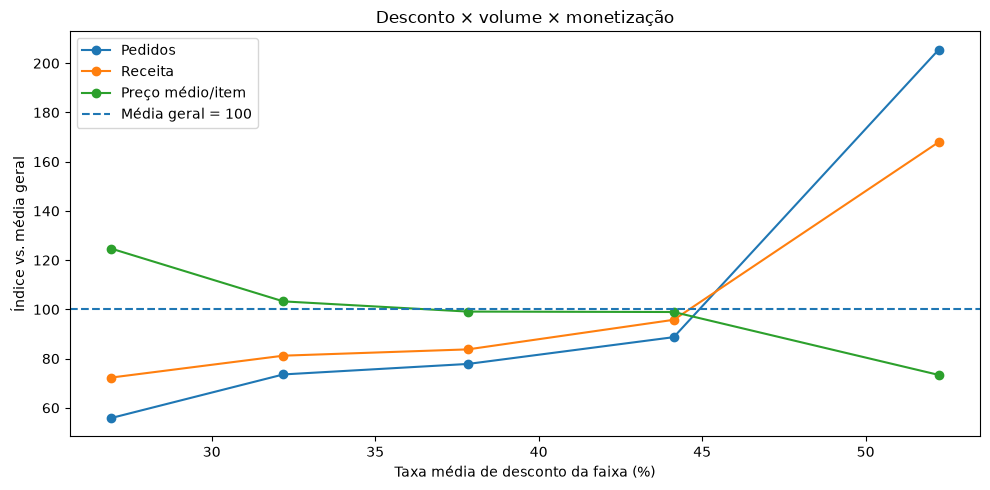

In [113]:
discount_quintiles_analysis = discount_quintiles.copy()

overall = {
    "pedidos_medio": daily["nr_pedidos"].mean(),
    "itens_medio": daily["qt_material"].mean(),
    "receita_media": daily["receita_aprovada"].mean(),
    "preco_medio_item": daily["preco_medio_item"].mean(),
    "ticket_medio": daily["ticket_medio"].mean(),
}

for metric, base_value in overall.items():
    discount_quintiles_analysis[f"indice_{metric}"] = (
        100
        * discount_quintiles_analysis[metric]
        / base_value
    )

display(
    discount_quintiles_analysis[
        [
            "faixa_desconto",
            "taxa_media",
            "pedidos_medio",
            "itens_medio",
            "receita_media",
            "preco_medio_item",
            "ticket_medio",
            "indice_pedidos_medio",
            "indice_receita_media",
            "indice_preco_medio_item",
        ]
    ]
)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    discount_quintiles_analysis["taxa_media"] * 100,
    discount_quintiles_analysis["indice_pedidos_medio"],
    marker="o",
    label="Pedidos",
)
ax.plot(
    discount_quintiles_analysis["taxa_media"] * 100,
    discount_quintiles_analysis["indice_receita_media"],
    marker="o",
    label="Receita",
)
ax.plot(
    discount_quintiles_analysis["taxa_media"] * 100,
    discount_quintiles_analysis["indice_preco_medio_item"],
    marker="o",
    label="Preço médio/item",
)

ax.axhline(
    100,
    linestyle="--",
    label="Média geral = 100",
)

ax.set_title("Desconto × volume × monetização")
ax.set_xlabel("Taxa média de desconto da faixa (%)")
ax.set_ylabel("Índice vs. média geral")
ax.legend()
fig.tight_layout()
plt.show()

### Como interpretar

Um cenário comercialmente interessante seria observar:

- índice de **pedidos acima de 100** nas faixas de maior desconto;
- índice de **preço médio abaixo de 100**;
- e verificar se a **receita fica acima ou abaixo de 100**.

Se pedidos aumentam e preço médio cai, mas a receita permanece ou cresce, o ganho de volume pode estar compensando a redução de preço. Se a receita também cai, a promoção pode estar sacrificando monetização sem volume suficiente para compensar.

**Cuidado:** esta análise é associativa. Dias promocionais, Black Friday, mix de categorias, canal e sazonalidade podem afetar simultaneamente desconto e demanda. Para medir efeito causal de desconto seria necessário desenho experimental ou uma abordagem causal específica.

### Implicação para o modelo

A **taxa de desconto realizada do próprio dia** não pode ser usada para prever esse mesmo dia, pois causaria leakage.

Por outro lado, se a empresa tiver um **plano promocional conhecido antecipadamente** — percentual planejado, campanha ou faixa de desconto — essa informação seria uma excelente feature exógena para o forecast.

## 4.3 Potencial de vendas por dia da semana

Comparamos **média e mediana**. A mediana reduz o efeito de datas promocionais extremas.

[BigQuery] potencial por dia da semana | estimativa processada: 3.42 MB


,dia_semana_num,dia_semana,dias,itens_media,itens_mediana,pedidos_media,receita_media,indice_potencial_itens
0,0,Segunda,35,"38,128.5143",27942,"25,287.5143","2,028,103.1451",0.9661
1,1,Terça,35,"43,206.2286",29995,"28,499.8571","2,162,365.5077",1.0371
2,2,Quarta,34,"43,115.3824",32567,"28,577.7353","2,104,828.8132",1.1261
3,3,Quinta,34,"45,675.0000",31463,"29,581.8824","2,104,095.3259",1.0879
4,4,Sexta,34,"51,330.9412",29553,"33,310.1471","2,371,419.2085",1.0219
5,5,Sábado,35,"36,921.7143",27265,"24,737.4571","1,892,664.8180",0.9427
6,6,Domingo,35,"28,374.2857",22781,"18,930.1143","1,533,385.1806",0.7877


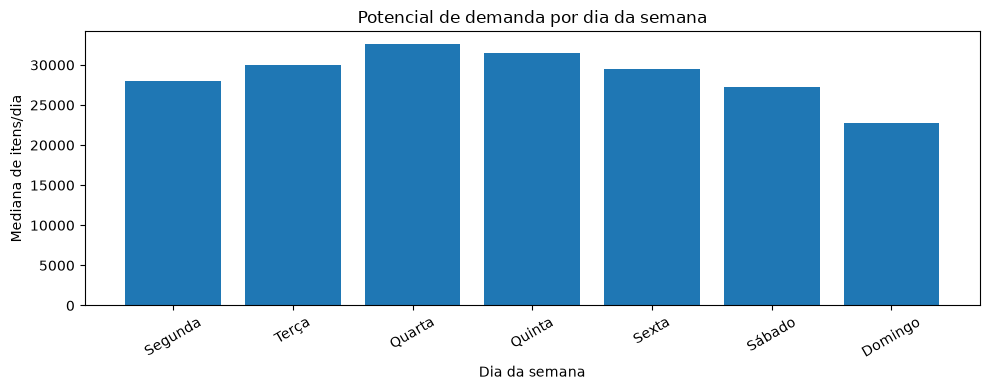

In [114]:
sql_weekday = f"""
WITH daily AS (
  SELECT
    DATE(dt_hr_venda) AS data,

    CASE EXTRACT(DAYOFWEEK FROM DATE(dt_hr_venda))
      WHEN 2 THEN 0
      WHEN 3 THEN 1
      WHEN 4 THEN 2
      WHEN 5 THEN 3
      WHEN 6 THEN 4
      WHEN 7 THEN 5
      WHEN 1 THEN 6
    END AS dia_semana_num,

    CASE EXTRACT(DAYOFWEEK FROM DATE(dt_hr_venda))
      WHEN 2 THEN 'Segunda'
      WHEN 3 THEN 'Terça'
      WHEN 4 THEN 'Quarta'
      WHEN 5 THEN 'Quinta'
      WHEN 6 THEN 'Sexta'
      WHEN 7 THEN 'Sábado'
      WHEN 1 THEN 'Domingo'
    END AS dia_semana,

    SUM(qt_material) AS qt_material,
    SUM(nr_pedidos) AS nr_pedidos,
    CAST(SUM(receita_aprovada) AS FLOAT64) AS receita_aprovada

  FROM `{TABLE_ID}`
  WHERE {DATE_FILTER}
  GROUP BY 1, 2, 3
),
global AS (
  SELECT
    APPROX_QUANTILES(qt_material, 100)[OFFSET(50)] AS mediana_global_itens
  FROM daily
)
SELECT
  d.dia_semana_num,
  d.dia_semana,
  COUNT(*) AS dias,
  AVG(d.qt_material) AS itens_media,
  APPROX_QUANTILES(d.qt_material, 100)[OFFSET(50)] AS itens_mediana,
  AVG(d.nr_pedidos) AS pedidos_media,
  AVG(d.receita_aprovada) AS receita_media,
  SAFE_DIVIDE(
    APPROX_QUANTILES(d.qt_material, 100)[OFFSET(50)],
    g.mediana_global_itens
  ) AS indice_potencial_itens
FROM daily d
CROSS JOIN global g
GROUP BY 1, 2, g.mediana_global_itens
ORDER BY 1
"""

weekday = run_bq(sql_weekday, "potencial por dia da semana")
display(weekday)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(weekday["dia_semana"], weekday["itens_mediana"])
ax.set_title("Potencial de demanda por dia da semana")
ax.set_xlabel("Dia da semana")
ax.set_ylabel("Mediana de itens/dia")
ax.tick_params(axis="x", rotation=30)
fig.tight_layout()
plt.show()

### Qual dia vence em cada semana?

O gráfico anterior compara a distribuição agregada por dia da semana. Agora olhamos **semana a semana** e identificamos qual dia teve maior demanda.

A linha tracejada mostra a **mediana da posição do dia vencedor**. Porém, para responder qual dia vence mais frequentemente, a estatística correta é a **moda/frequência**, mostrada logo depois.

[BigQuery] dia vencedor por semana | estimativa processada: 1.37 MB


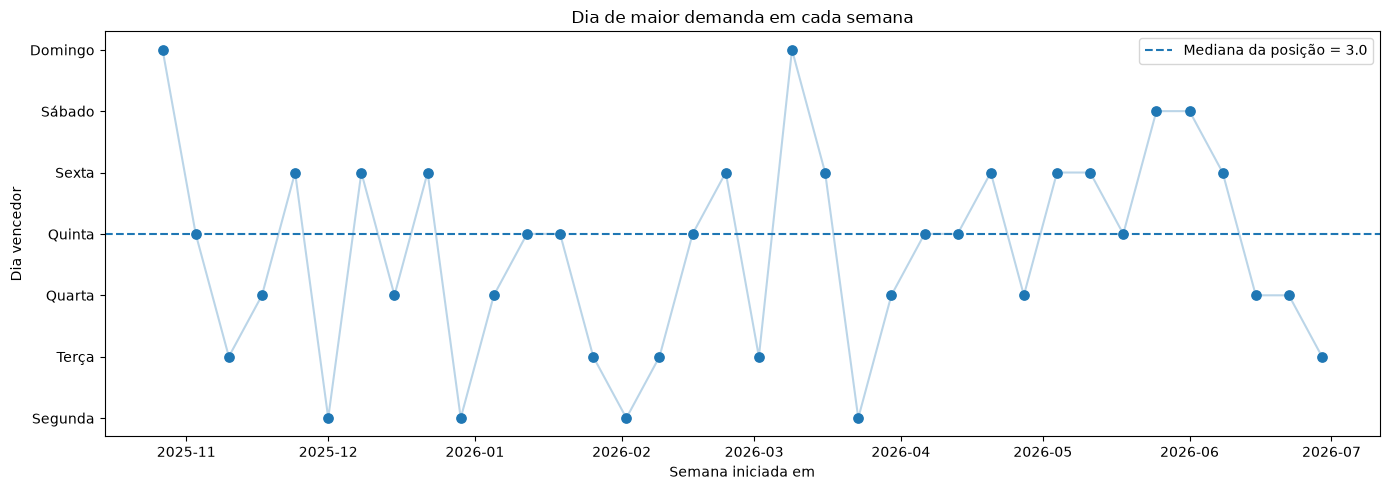

,dia_semana,semanas_vencedoras,pct_semanas
0,Segunda,4,0.1111
1,Terça,5,0.1389
2,Quarta,7,0.1944
3,Quinta,7,0.1944
4,Sexta,9,0.2500
5,Sábado,2,0.0556
6,Domingo,2,0.0556


Dia que mais venceu semanas (moda): Sexta


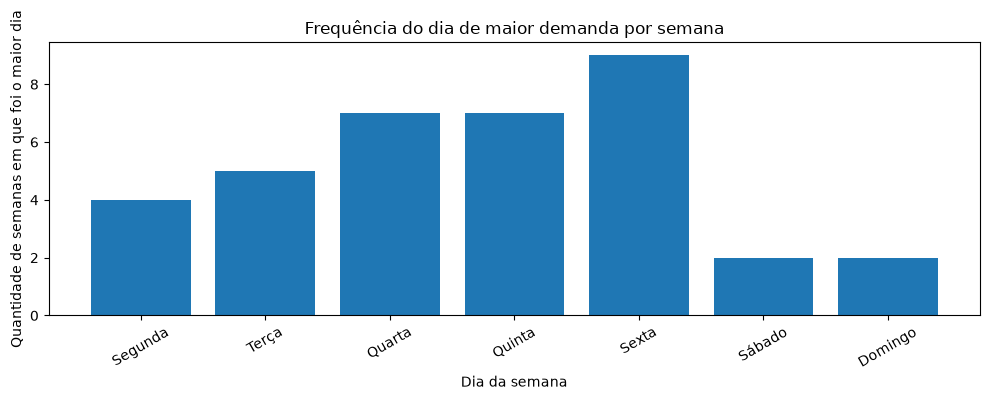

In [115]:
sql_weekly_winners = f"""
WITH daily AS (
  SELECT
    DATE(dt_hr_venda) AS data,
    DATE_TRUNC(DATE(dt_hr_venda), WEEK(MONDAY)) AS semana_inicio,

    CASE EXTRACT(DAYOFWEEK FROM DATE(dt_hr_venda))
      WHEN 2 THEN 0
      WHEN 3 THEN 1
      WHEN 4 THEN 2
      WHEN 5 THEN 3
      WHEN 6 THEN 4
      WHEN 7 THEN 5
      WHEN 1 THEN 6
    END AS dia_semana_num,

    CASE EXTRACT(DAYOFWEEK FROM DATE(dt_hr_venda))
      WHEN 2 THEN 'Segunda'
      WHEN 3 THEN 'Terça'
      WHEN 4 THEN 'Quarta'
      WHEN 5 THEN 'Quinta'
      WHEN 6 THEN 'Sexta'
      WHEN 7 THEN 'Sábado'
      WHEN 1 THEN 'Domingo'
    END AS dia_semana,

    SUM(qt_material) AS qt_material

  FROM `{TABLE_ID}`
  WHERE {DATE_FILTER}
  GROUP BY 1, 2, 3, 4
),
ranked AS (
  SELECT
    *,
    ROW_NUMBER() OVER (
      PARTITION BY semana_inicio
      ORDER BY qt_material DESC, data
    ) AS rn
  FROM daily
)
SELECT
  semana_inicio,
  data,
  dia_semana_num,
  dia_semana,
  qt_material
FROM ranked
WHERE rn = 1
ORDER BY semana_inicio
"""

weekly_winners = run_bq(
    sql_weekly_winners,
    "dia vencedor por semana",
)
weekly_winners["semana_inicio"] = pd.to_datetime(weekly_winners["semana_inicio"])
weekly_winners["data"] = pd.to_datetime(weekly_winners["data"])

weekday_labels = [
    "Segunda",
    "Terça",
    "Quarta",
    "Quinta",
    "Sexta",
    "Sábado",
    "Domingo",
]

median_winner = float(weekly_winners["dia_semana_num"].median())

fig, ax = plt.subplots(figsize=(14, 5))
ax.scatter(
    weekly_winners["semana_inicio"],
    weekly_winners["dia_semana_num"],
    s=45,
)
ax.plot(
    weekly_winners["semana_inicio"],
    weekly_winners["dia_semana_num"],
    alpha=0.3,
)
ax.axhline(
    median_winner,
    linestyle="--",
    label=f"Mediana da posição = {median_winner:.1f}",
)
ax.set_yticks(range(7))
ax.set_yticklabels(weekday_labels)
ax.set_title("Dia de maior demanda em cada semana")
ax.set_xlabel("Semana iniciada em")
ax.set_ylabel("Dia vencedor")
ax.legend()
fig.tight_layout()
plt.show()

winner_frequency = (
    weekly_winners["dia_semana"]
    .value_counts()
    .reindex(weekday_labels, fill_value=0)
    .rename_axis("dia_semana")
    .reset_index(name="semanas_vencedoras")
)

winner_frequency["pct_semanas"] = (
    winner_frequency["semanas_vencedoras"]
    / winner_frequency["semanas_vencedoras"].sum()
)

display(winner_frequency)

winner_mode = winner_frequency.loc[
    winner_frequency["semanas_vencedoras"].idxmax(),
    "dia_semana",
]
print(f"Dia que mais venceu semanas (moda): {winner_mode}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(
    winner_frequency["dia_semana"],
    winner_frequency["semanas_vencedoras"],
)
ax.set_title("Frequência do dia de maior demanda por semana")
ax.set_xlabel("Dia da semana")
ax.set_ylabel("Quantidade de semanas em que foi o maior dia")
ax.tick_params(axis="x", rotation=30)
fig.tight_layout()
plt.show()

## 4.4 Flutuação ao longo do dia

Para evitar que dias de grande volume dominem a análise, calculamos a **participação de cada hora no total de seu próprio dia** e só depois fazemos a média entre os dias.

[BigQuery] perfil intradiário | estimativa processada: 3.42 MB


,hora,receita_media,pedidos_media,itens_media,share_receita_media,share_itens_media
0,0,"42,600.9350",630.1694,"1,002.0248",0.0203,0.0228
1,1,"21,349.3745",331.5248,530.0041,0.0104,0.0124
2,2,"11,390.4952",174.9752,276.4421,0.0056,0.0067
3,3,"7,142.1881",109.4380,174.2975,0.0036,0.0043
4,4,"6,261.4588",94.4339,149.9711,0.0030,0.0036
5,5,"11,069.3015",160.4752,254.1694,0.0051,0.0055
6,6,"26,101.4783",366.7975,569.8347,0.0120,0.0126
7,7,"52,096.9040",705.0165,"1,086.5785",0.0247,0.0249
8,8,"81,325.4243","1,052.8430","1,595.7107",0.0387,0.0377
9,9,"110,460.5357","1,404.4215","2,108.1570",0.0538,0.0519


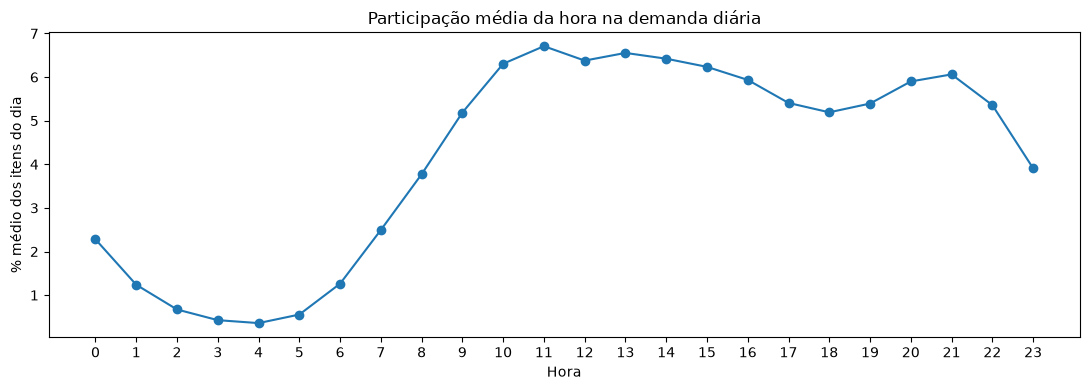

In [116]:
sql_hourly = f"""
WITH hourly_daily AS (
  SELECT
    DATE(dt_hr_venda) AS data,
    EXTRACT(HOUR FROM dt_hr_venda) AS hora,
    CAST(SUM(receita_aprovada) AS FLOAT64) AS receita_aprovada,
    SUM(nr_pedidos) AS nr_pedidos,
    SUM(qt_material) AS qt_material
  FROM `{TABLE_ID}`
  WHERE {DATE_FILTER}
  GROUP BY 1, 2
),
shares AS (
  SELECT
    *,
    SAFE_DIVIDE(receita_aprovada, SUM(receita_aprovada) OVER (PARTITION BY data)) AS share_receita,
    SAFE_DIVIDE(qt_material, SUM(qt_material) OVER (PARTITION BY data)) AS share_itens
  FROM hourly_daily
)
SELECT
  hora,
  AVG(receita_aprovada) AS receita_media,
  AVG(nr_pedidos) AS pedidos_media,
  AVG(qt_material) AS itens_media,
  AVG(share_receita) AS share_receita_media,
  AVG(share_itens) AS share_itens_media
FROM shares
GROUP BY 1
ORDER BY 1
"""

hourly = run_bq(sql_hourly, "perfil intradiário")
display(hourly)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(hourly["hora"], hourly["share_itens_media"] * 100, marker="o")
ax.set_title("Participação média da hora na demanda diária")
ax.set_xlabel("Hora")
ax.set_ylabel("% médio dos itens do dia")
ax.set_xticks(range(24))
fig.tight_layout()
plt.show()

### Heatmap dia da semana × hora

[BigQuery] dia da semana x hora | estimativa processada: 1.37 MB


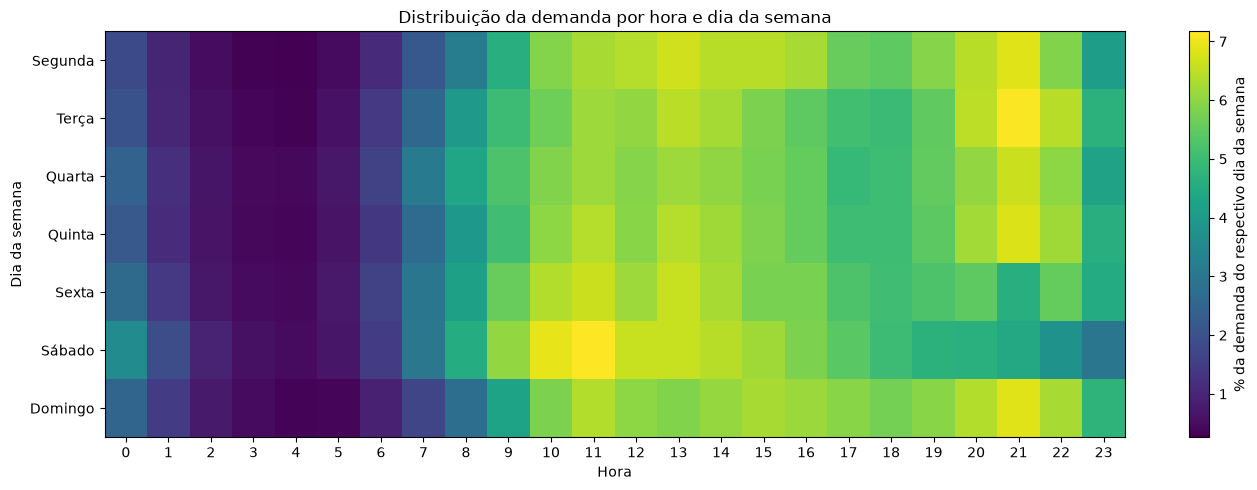

In [117]:
sql_hour_dow = f"""
WITH base AS (
  SELECT
    CASE EXTRACT(DAYOFWEEK FROM DATE(dt_hr_venda))
      WHEN 2 THEN 0
      WHEN 3 THEN 1
      WHEN 4 THEN 2
      WHEN 5 THEN 3
      WHEN 6 THEN 4
      WHEN 7 THEN 5
      WHEN 1 THEN 6
    END AS dia_semana_num,

    CASE EXTRACT(DAYOFWEEK FROM DATE(dt_hr_venda))
      WHEN 2 THEN 'Segunda'
      WHEN 3 THEN 'Terça'
      WHEN 4 THEN 'Quarta'
      WHEN 5 THEN 'Quinta'
      WHEN 6 THEN 'Sexta'
      WHEN 7 THEN 'Sábado'
      WHEN 1 THEN 'Domingo'
    END AS dia_semana,

    EXTRACT(HOUR FROM dt_hr_venda) AS hora,
    SUM(qt_material) AS qt_material
  FROM `{TABLE_ID}`
  WHERE {DATE_FILTER}
  GROUP BY 1, 2, 3
),
share AS (
  SELECT
    *,
    SAFE_DIVIDE(
      qt_material,
      SUM(qt_material) OVER (PARTITION BY dia_semana_num)
    ) AS share
  FROM base
)
SELECT *
FROM share
ORDER BY dia_semana_num, hora
"""

hour_dow = run_bq(sql_hour_dow, "dia da semana x hora")

heat = (
    hour_dow.pivot(index="dia_semana", columns="hora", values="share")
    .reindex(["Segunda", "Terça", "Quarta", "Quinta", "Sexta", "Sábado", "Domingo"])
)

fig, ax = plt.subplots(figsize=(14, 5))
image = ax.imshow(heat.to_numpy() * 100, aspect="auto")
ax.set_title("Distribuição da demanda por hora e dia da semana")
ax.set_xlabel("Hora")
ax.set_ylabel("Dia da semana")
ax.set_xticks(range(24))
ax.set_xticklabels(range(24))
ax.set_yticks(range(len(heat.index)))
ax.set_yticklabels(heat.index)
cbar = fig.colorbar(image, ax=ax)
cbar.set_label("% da demanda do respectivo dia da semana")
fig.tight_layout()
plt.show()

# 5. Relações entre métricas — Python

A partir daqui usamos a pequena visão diária já agregada pelo BigQuery. Correlação é uma ferramenta exploratória, não causalidade.

,receita_aprovada,nr_pedidos,qt_material,vlr_venda_desconto,preco_medio_item,ticket_medio,itens_por_pedido
receita_aprovada,1.0000,0.9365,0.9022,0.8575,-0.3396,-0.3734,0.2107
nr_pedidos,0.9365,1.0000,0.9832,0.8905,-0.5943,-0.6483,0.3462
qt_material,0.9022,0.9832,1.0000,0.9146,-0.6750,-0.6793,0.4775
vlr_venda_desconto,0.8575,0.8905,0.9146,1.0000,-0.5703,-0.5465,0.4800
preco_medio_item,-0.3396,-0.5943,-0.6750,-0.5703,1.0000,0.9427,-0.7862
ticket_medio,-0.3734,-0.6483,-0.6793,-0.5465,0.9427,1.0000,-0.5706
itens_por_pedido,0.2107,0.3462,0.4775,0.4800,-0.7862,-0.5706,1.0000


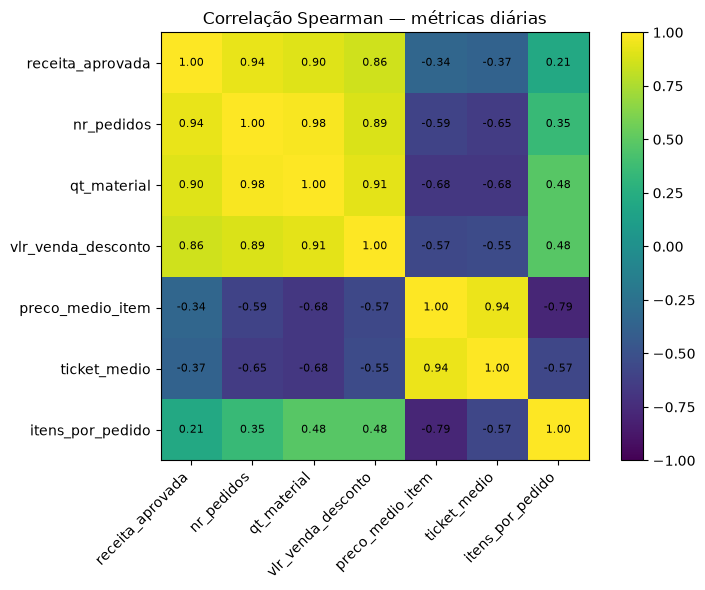

In [118]:
corr_columns = [
    "receita_aprovada",
    "nr_pedidos",
    "qt_material",
    "vlr_venda_desconto",
    "preco_medio_item",
    "ticket_medio",
    "itens_por_pedido",
]

corr = daily[corr_columns].corr(method="spearman")
display(corr)

fig, ax = plt.subplots(figsize=(8, 6))
image = ax.imshow(corr.to_numpy(), vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr.index)))
ax.set_yticklabels(corr.index)
ax.set_title("Correlação Spearman — métricas diárias")

for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

fig.colorbar(image, ax=ax)
fig.tight_layout()
plt.show()

# 6. Model Readiness

### Target proposto
**`qt_material` diário**, por representar diretamente a demanda operacional em unidades.

`receita_aprovada` permanece como KPI financeiro e pode ser modelada em uma análise complementar.

### Risco de leakage
Para prever o dia *t*, métricas realizadas do próprio dia *t* não podem ser features: receita, pedidos, itens, desconto e mix realizado do mesmo período só existem depois da venda.

### Features candidatas
- calendário: dia da semana, mês, fim de semana;
- lags `t-1`, `t-7`, `t-14`, `t-28`;
- rolling mean/std calculados apenas com passado;
- lags de preço médio, receita e pedidos;
- tendência temporal;
- feriados/datas comerciais, caso sejam adicionados como fonte conhecida antes da previsão.

### Validação
Split aleatório não é apropriado. Usaremos **backtest temporal / expanding window**.

### Baselines obrigatórios
- naive t-1;
- naive sazonal t-7;
- média móvel histórica.

### Métricas
MAE, WAPE, Bias e Skill vs baseline. MAPE será tratado com cautela.

# 7. Resumo executivo

In [119]:
top_day = top_days.iloc[0]
top_weekday = weekday.loc[weekday["itens_mediana"].idxmax()]
bottom_weekday = weekday.loc[weekday["itens_mediana"].idxmin()]
peak_hour = hourly.loc[hourly["share_itens_media"].idxmax()]

executive_summary = pd.DataFrame([
    {
        "tema": "Data Quality",
        "insight": (
            f"{float(invalid_category.loc[0, 'pct_categoria_invalida']):.2%} "
            "das linhas possuem categoria inválida."
        ),
        "implicacao": "Preservar vendas nos totais e excluir apenas de análises categóricas.",
    },
    {
        "tema": "Receita negativa",
        "insight": (
            f"{float(negative_revenue.loc[0, 'pct_linhas_negativas']):.2%} "
            "das linhas têm receita negativa."
        ),
        "implicacao": "Validar estorno/devolução/ajuste antes de qualquer tratamento.",
    },
    {
        "tema": "Maior dia de demanda",
        "insight": f"{top_day['data']} — {int(top_day['qt_material']):,} itens.",
        "implicacao": "Picos legítimos devem ser aprendidos pelo modelo, não removidos mecanicamente.",
    },
    {
        "tema": "Dia da semana",
        "insight": (
            f"Maior mediana: {top_weekday['dia_semana']}; "
            f"menor: {bottom_weekday['dia_semana']}."
        ),
        "implicacao": "Dia da semana é uma feature relevante.",
    },
    {
        "tema": "Intradiário",
        "insight": f"Hora de maior participação média: {int(peak_hour['hora'])}h.",
        "implicacao": "Existe padrão horário relevante para planejamento operacional.",
    },
])

display(executive_summary)

,tema,insight,implicacao
0,Data Quality,5.96% das linhas possuem categoria inválida.,Preservar vendas nos totais e excluir apenas d...
1,Receita negativa,3.92% das linhas têm receita negativa.,Validar estorno/devolução/ajuste antes de qual...
2,Maior dia de demanda,"2025-11-28 00:00:00 — 422,860 itens.",Picos legítimos devem ser aprendidos pelo mode...
3,Dia da semana,Maior mediana: Quarta; menor: Domingo.,Dia da semana é uma feature relevante.
4,Intradiário,Hora de maior participação média: 11h.,Existe padrão horário relevante para planejame...
